# SMALL BUSINESS ADMINISTRATION (SBA) ANALYSIS

### ABSTRACT

This study analyzed **U.S. Small Business Administration (SBA) loan data from 1987–2014** to uncover patterns in approvals, disbursements, and repayment outcomes. After rigorous **data cleaning and preparation, exploratory analysis highlighted temporal trends, industry and state-level variations, and the persistent risk of loan default.** Feature importance analysis showed loan term, bank affiliation, industry type, and approval amounts as the most critical determinants of repayment. Multiple machine learning models were tested, with **XGBoost** achieving the best balance of accuracy and efficiency **(ROC-AUC = 0.977, accuracy = 94%)** for predicting loan status, while Gradient Boosting provided the lowest RMSE for regression tasks such as approval amount prediction. Overall, the findings demonstrate the value of predictive analytics in assessing SBA loan risk and informing data-driven lending decisions.

### Background

**Small businesses play a vital role in driving economic growth, creating jobs, and supporting local communities.** In the United States, many of these businesses rely on financing from the Small Business Administration (SBA) to **start, expand, or recover from setbacks.** Now the Small Business Administration **does not directly give or lend money directly** to the small businesses but **guarantees a portion** or whole of the loans issued by other lenders. However, some small businesses are unable to repay the whole loan. Some are **“Paid in Full” (PIF)**, while others are **“Charged Off”** (defaulted), which can lead to financial losses for lenders and the SBA.

**Understanding the characteristics of loans that succeed versus those that fail is important** for both policymakers and lenders. By analyzing historical SBA loan data, we can **uncover patterns, identify the main risk factors, and develop models to predict outcomes** before the loans are issued. **This knowledge can help in making more informed lending decisions, reducing defaults, and ensuring that SBA resources are used effectively to support viable businesses.**

### Research Problem

Over many years, the SBA has provided hundreds of thousands of loans to small businesses spanning various industries, states, and economic conditions. While a good number of these loans **are paid back successfully, some unfortunately end up in default.** This results in financial losses and reduces the funds available to support future borrowers. Even though there is a vast amount of historical loan data available, many organizations still rely on broad credit rules or manual evaluations—methods that can miss subtle but important patterns hidden within the data.

**The real challenge lies in how to make the most of this rich historical information to better predict how loans will perform.** More specifically, there’s a need to pinpoint which financial, demographic, and timing **factors affect whether a loan gets repaid.** From there, building accurate predictive models that can distinguish between loans likely to be repaid and those likely to default becomes essential. Besides just categorizing loans, being able to forecast key loan details-like the SBA approval amount and loan duration-would also empower lenders to tailor financing options more effectively. Without these insights, decisions tend to be reactive instead of forward-thinking, which limits the SBA’s ability to manage risks and make the greatest impact.

In short, by going beyond simply predicting loan outcomes and also estimating things like approval amounts and terms, lenders can have stronger tools to help them structure loan offers in ways that better meet borrowers’ needs.

### Objectives.
**1. To explore and describe patterns in the SBA dataset.**

**2. To identify key financial, demographic, and temporal factors influencing loan repayment outcomes.**

**3. To develop and evaluate Classification machine learning models capable of classifying SBA loans as “Paid in Full” or “Charged Off” prior to disbursement** 

**4. To develop a machine learning model able predict the SBA approval amount (SBA_Appv)**.

### Methodology

#### Data

## **Data Description**

The dataset used for this analysis is **derived from the U.S. Small Business Administration (SBA) loan records** and contains 899,164 observations with 27 variables. Each record represents a loan disbursed to a small business between January 1987 and December 2014, capturing details about the borrower, the bank, loan terms, amounts approved and disbursed, and the **final loan performance outcome.** The key target variable for this project is `MIS_Status`, which indicates whether a loan was “Paid in Full” (PIF) or “Charged Off” (defaulted). The dataset contains both **categorical and numerical attributes**, allowing for a wide range of analyses, from descriptive and diagnostic analytics to predictive modeling. The data was extracted from the **SBA’s internal loan guarantee system** and published as part of transparency and open data initiatives. It was compiled into a machine-readable format by the academic and data science community for research purposes. The loans included in this dataset were issued under SBA’s policy frameworks, and some variation or inconsistencies may occur due to differences in historical record formats, particularly in earlier years. The dataset is rich in information, enabling the exploration of historical trends in loan issuance and repayment, as well as the construction of predictive models to support better decision-making in loan approvals and risk management.

**Source of Data:** Public dataset from [https://pengdsci.github.io/datasets](https://pengdsci.github.io/datasets), originally from the U.S. Small Business Administration (SBA).  
**Period Collected:** January 1987 – December 2014.  
**How it Was Collected:** Extracted from the **SBA’s internal loan guarantee system and published as part of transparency** and open data efforts, later compiled into machine-readable format by researchers.  
**Conditions:** Loans issued to qualifying small businesses under SBA guarantee programs, meeting eligibility criteria at the time. Some data points may reflect reporting delays or formatting inconsistencies from historical records.  

---

### **Variable Description Table (Split View(899164, 27))**

<div style="display: flex; justify-content: space-between;">

<!-- Left Column -->
<div style="width: 48%;">

### **Column 1**

<table>
<thead>
<tr>
<th>Variable Name</th>
<th>Data Type</th>
<th>Description</th>
</tr>
</thead>
<tbody>
<tr><td>LoanNr_ChkDgt</td><td>Text</td><td>Identifier – Primary Key</td></tr>
<tr><td>Name</td><td>Text</td><td>Borrower Name</td></tr>
<tr><td>City</td><td>Text</td><td>Borrower City</td></tr>
<tr><td>State</td><td>Text</td><td>Borrower State</td></tr>
<tr><td>Zip</td><td>Text</td><td>Borrower Zip Code</td></tr>
<tr><td>Bank</td><td>Text</td><td>Bank Name</td></tr>
<tr><td>BankState</td><td>Text</td><td>Bank State</td></tr>
<tr><td>NAICS</td><td>Text</td><td>Industry Classification (NAICS code)</td></tr>
<tr><td>ApprovalDate</td><td>Date/Time</td><td>Date SBA Commitment Issued</td></tr>
<tr><td>ApprovalFY</td><td>Text</td><td>Fiscal Year of Commitment</td></tr>
<tr><td>Term</td><td>Number</td><td>Loan term in months</td></tr>
<tr><td>NoEmp</td><td>Number</td><td>Number of Business Employees</td></tr>
<tr><td>NewExist</td><td>Text</td><td>1 = Existing, 2 = New Business</td></tr>
</tbody>
</table>

</div>

<!-- Right Column -->
<div style="width: 48%;">

### **Column 2**

<table>
<thead>
<tr>
<th>Variable Name</th>
<th>Data Type</th>
<th>Description</th>
</tr>
</thead>
<tbody>
<tr><td>CreateJob</td><td>Number</td><td>Number of jobs created</td></tr>
<tr><td>RetainedJob</td><td>Number</td><td>Number of jobs retained</td></tr>
<tr><td>FranchiseCode</td><td>Text</td><td>Franchise Code (00000 or 00001 = No Franchise)</td></tr>
<tr><td>UrbanRural</td><td>Text</td><td>1 = Urban, 2 = Rural, 0 = Undefined</td></tr>
<tr><td>RevLineCr</td><td>Text</td><td>Revolving Line of Credit: Y = Yes</td></tr>
<tr><td>LowDoc</td><td>Text</td><td>LowDoc Loan Program: Y = Yes, N = No</td></tr>
<tr><td>ChgOffDate</td><td>Date/Time</td><td>Date loan was charged off</td></tr>
<tr><td>DisbursementDate</td><td>Date/Time</td><td>Date loan was disbursed</td></tr>
<tr><td>DisbursementGross</td><td>Currency</td><td>Amount Disbursed</td></tr>
<tr><td>BalanceGross</td><td>Currency</td><td>Gross amount outstanding</td></tr>
<tr><td>MIS_Status</td><td>Text</td><td>Loan Status: PIF or CHGOFF</td></tr>
<tr><td>ChgOffPrinGr</td><td>Currency</td><td>Charged-off Amount</td></tr>
<tr><td>GrAppv</td><td>Currency</td><td>Gross Loan Amount Approved</td></tr>
<tr><td>SBA_Appv</td><td>Currency</td><td>SBA’s Guaranteed Approved Amount</td></tr>
</tbody>
</table>

</div>

</div>

### Results 

### Discussion

## Data cleaning.

**steps**
- Preliminary check
- Clean Column Names
- Standardize Data Types
- Check for duplicate rows
- Clean and standardize text data
- Correction of ZIP codes
- Standardize Columns (`rev_line_cr`, `low_doc`)
- Missing Data Visualization with `missingno`

In [1]:
# %pip install pandas numpy matplotlib seaborn tqdm missingno rapidfuzz
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
from rapidfuzz import process, fuzz
from tqdm import tqdm

In [2]:
file_list = [
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational01 (1).csv",
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational02.csv",
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational03.csv",
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational04.csv",
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational05.csv",
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational06.csv",
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational07.csv",
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational08.csv",
    "C:/Users/mickey/Desktop/su work/1.1/data mining/project data/w06-SBAnational09.csv"
]

dfs = [pd.read_csv(file, index_col=0, low_memory=False) for file in file_list]
sba = pd.concat(dfs, ignore_index=False)
sba.reset_index(drop=True, inplace=True)
print(" Final SBA dataset shape:", sba.shape)
sba.head()

 Final SBA dataset shape: (899164, 27)


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [3]:
print("COLUMN NAMES:")
columns = sba.columns.tolist()
for i in range(0, len(columns), 10):
    print(columns[i:i+10])
print("=" * 100)

print("SHAPE (rows, columns):")
print(sba.shape)
print("=" * 100)

print("DATA TYPES:")
print(sba.dtypes)
print("=" * 100)

print(" MISSING VALUES SUMMARY:")
missing_df = pd.DataFrame({
    'Missing_Count': sba.isnull().sum(),
    'Missing_Percent': (sba.isnull().sum() / len(sba) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent', ascending=False)
display(missing_df)
print("=" * 100)

print("UNIQUE VALUES PER COLUMN:")
print(sba.nunique())
print("=" * 50)

print("DESCRIPTIVE STATS (NUMERIC):")
print(sba.describe())
print("=" * 100)

COLUMN NAMES:
['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState', 'NAICS', 'ApprovalDate', 'ApprovalFY']
['Term', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'ChgOffDate']
['DisbursementDate', 'DisbursementGross', 'BalanceGross', 'MIS_Status', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']
SHAPE (rows, columns):
(899164, 27)
DATA TYPES:
LoanNr_ChkDgt          int64
Name                  object
City                  object
State                 object
Zip                    int64
Bank                  object
BankState             object
NAICS                  int64
ApprovalDate          object
ApprovalFY            object
Term                   int64
NoEmp                  int64
NewExist             float64
CreateJob              int64
RetainedJob            int64
FranchiseCode          int64
UrbanRural             int64
RevLineCr             object
LowDoc                object
ChgOffDate            object
Disbursement

,Missing_Count,Missing_Percent
ChgOffDate,736465,81.91
RevLineCr,4528,0.50
LowDoc,2582,0.29
DisbursementDate,2368,0.26
MIS_Status,1997,0.22
BankState,1566,0.17
Bank,1559,0.17
NewExist,136,0.02
State,14,0.00
Name,14,0.00


UNIQUE VALUES PER COLUMN:
LoanNr_ChkDgt        899164
Name                 779583
City                  32581
State                    51
Zip                   33611
Bank                   5802
BankState                56
NAICS                  1312
ApprovalDate           9859
ApprovalFY               71
Term                    412
NoEmp                   599
NewExist                  3
CreateJob               246
RetainedJob             358
FranchiseCode          2768
UrbanRural                3
RevLineCr                18
LowDoc                    8
ChgOffDate             6448
DisbursementDate       8472
DisbursementGross    118859
BalanceGross             15
MIS_Status                2
ChgOffPrinGr          83165
GrAppv                22128
SBA_Appv              38326
dtype: int64
DESCRIPTIVE STATS (NUMERIC):
       LoanNr_ChkDgt            Zip          NAICS           Term  \
count   8.991640e+05  899164.000000  899164.000000  899164.000000   
mean    4.772612e+09   53804.391241  3

#### Clean Column Names.
To ensure consistency, we apply a custom cleaning function that will:-

- **Replacing symbols and spaces with underscores**
- **Converting camelCase to snake_case**
- **Lowercasing all characters**
- **Removing duplicate underscores**
- **Ensuring each name is a valid and unique Python identifier**

In [4]:
import re

def clean_column_names(columns):
    seen = {}
    cleaned_cols = []

    for col in columns:
        # 1. Replace symbols (spaces, dots, dashes, slashes, etc.) with underscores
        col = re.sub(r'[^0-9a-zA-Z]+', '_', col)

        # 2. Insert underscores between lowercase and uppercase (camelCase → snake_case)
        col = re.sub(r'(?<=[a-z])(?=[A-Z])', '_', col)

        # 3. Lowercase everything
        col = col.lower()

        # 4. Remove multiple underscores
        col = re.sub(r'_+', '_', col)

        # 5. Strip leading/trailing underscores or whitespace
        col = col.strip('_').strip()

        # 6. Ensure valid Python identifier
        if not re.match(r'^[a-zA-Z_]', col):
            col = '_' + col
        col = re.sub(r'[^0-9a-zA-Z_]', '', col)

        # 7. Make names unique if duplicates occur
        base = col
        i = 1
        while col in seen:
            col = f"{base}__{i}"
            i += 1
        seen[col] = True

        cleaned_cols.append(col)

    return cleaned_cols

# Apply cleaning to the SBA dataset column names
sba.columns = clean_column_names(sba.columns)

# Print cleaned column names, 10 per line
print(" CLEANED COLUMN NAMES:\n")
for i in range(0, len(sba.columns), 10):
    print(sba.columns[i:i+10])

 CLEANED COLUMN NAMES:

Index(['loan_nr_chk_dgt', 'name', 'city', 'state', 'zip', 'bank', 'bank_state',
       'naics', 'approval_date', 'approval_fy'],
      dtype='object')
Index(['term', 'no_emp', 'new_exist', 'create_job', 'retained_job',
       'franchise_code', 'urban_rural', 'rev_line_cr', 'low_doc',
       'chg_off_date'],
      dtype='object')
Index(['disbursement_date', 'disbursement_gross', 'balance_gross',
       'mis_status', 'chg_off_prin_gr', 'gr_appv', 'sba_appv'],
      dtype='object')


#### **Standardize Data Types**

For consistency we will standardize the columns(column content):-

- **Currency columns** are cleaned by removing dollar signs and commas, then converted to numeric (`float`) format.
- **Date columns** are parsed into proper `datetime` objects, gracefully handling any invalid entries.
- **Approval_fy** is stripped of whitespace and converted to an integer format.
- **Categorical variables** such as `mis_status`, `new_exist`, `urban_rural`, and `naics` are converted to meaningful labeled categories to enhance interpretability and memory efficiency.

In [5]:
money_cols = ['disbursement_gross', 'balance_gross', 'chg_off_prin_gr', 'gr_appv', 'sba_appv']
for col in money_cols:
    sba[col] = sba[col].replace('[\$,]', '', regex=True).astype(float)

date_cols = ['approval_date', 'disbursement_date', 'chg_off_date']
for col in date_cols:
    sba[col] = pd.to_datetime(sba[col], errors='coerce')

sba['approval_fy'] = pd.to_numeric(sba['approval_fy'].astype(str).str.strip(), errors='coerce').astype('Int64')

sba['mis_status'] = sba['mis_status'].astype('category')

sba['new_exist'] = sba['new_exist'].map({1: 'Existing', 2: 'New'}).fillna('Unknown').astype('category')

urban_rural_map = {0: 'Undefined', 1: 'Urban', 2: 'Rural'}
sba['urban_rural'] = sba['urban_rural'].map(urban_rural_map).fillna('Unknown').astype('category')

sba['naics'] = sba['naics'].fillna('Unknown').astype('category')

print(sba.dtypes)

loan_nr_chk_dgt                int64
name                          object
city                          object
state                         object
zip                            int64
bank                          object
bank_state                    object
naics                       category
approval_date         datetime64[ns]
approval_fy                    Int64
term                           int64
no_emp                         int64
new_exist                   category
create_job                     int64
retained_job                   int64
franchise_code                 int64
urban_rural                 category
rev_line_cr                   object
low_doc                       object
chg_off_date          datetime64[ns]
disbursement_date     datetime64[ns]
disbursement_gross           float64
balance_gross                float64
mis_status                  category
chg_off_prin_gr              float64
gr_appv                      float64
sba_appv                     float64
d

#### Check for duplicate rows.

In [6]:
duplicate_count = sba.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
sba = sba.drop_duplicates()
print("Shape after removing duplicates:", sba.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (899164, 27)


In [7]:
### check the index column if clean and reset.
sba.index

RangeIndex(start=0, stop=899164, step=1)

#### Clean and standardize text data

In [8]:
text_cols_to_clean = ['name', 'city', 'state', 'bank', 'bank_state']

for col in text_cols_to_clean:
    # Ensure the column is of string type before applying string operations
    sba[col] = sba[col].astype(str).str.lower().str.strip()

print("Sample of cleaned 'name' column:")
display(sba['name'].head())

print("\nSample of cleaned 'city' column:")
display(sba['city'].head())

print("\nSample of cleaned 'state' column:")
display(sba['state'].head())

print("\nSample of cleaned 'bank' column:")
display(sba['bank'].head())

print("\nSample of cleaned 'bankstate' column:")
display(sba['bank_state'].head())

Sample of cleaned 'name' column:


0                   abc hobbycraft
1      landmark bar & grille (the)
2            whitlock dds, todd m.
3    big bucks pawn & jewelry, llc
4      anastasia confections, inc.
Name: name, dtype: object


Sample of cleaned 'city' column:


0      evansville
1       new paris
2     bloomington
3    broken arrow
4         orlando
Name: city, dtype: object


Sample of cleaned 'state' column:


0    in
1    in
2    in
3    ok
4    fl
Name: state, dtype: object


Sample of cleaned 'bank' column:


0                 fifth third bank
1                  1st source bank
2          grant county state bank
3    1st natl bk & tr co of broken
4          florida bus. devel corp
Name: bank, dtype: object


Sample of cleaned 'bankstate' column:


0    oh
1    in
2    in
3    ok
4    fl
Name: bank_state, dtype: object

#### **Standardize Columns (`rev_line_cr`, `low_doc`)**
In this step, we cleaned and standardized two important binary columns:
- `rev_line_cr`.
- `low_doc`.
The cleaning steps include:
- Converting all entries to **uppercase strings** for consistency.
- Removing **extra whitespace**.
- Imputing missing values with the label `"Unknown"`.
- Converting both columns to the `category` data type.

In [9]:
# Fill missing values with 'Unknown' and convert to categorical for both columns
flag_cols = ['rev_line_cr', 'low_doc']
for col in flag_cols:
    sba[col] = (
        sba[col]
        .astype(str)                        # Convert to string
        .str.strip().str.upper()            # Standardize formatting
        .replace({'': np.nan, 'NONE': np.nan})  # Treat blanks and 'NONE' as missing
        .fillna('Unknown')                  # Impute missing with 'Unknown'
        .astype('category')                 # Convert to category for efficiency
    )
    print("Unique values in 'low_doc':")
print(sba['low_doc'].value_counts(dropna=False))


def clean_low_doc(val):
    if pd.isna(val) or str(val).strip().upper() in ['', 'NAN']:
        return 'unknown'
    val = str(val).strip().upper()
    if val in ['Y', '1']:
        return 'Y'
    elif val in ['N', '0']:
        return 'N'
    else:
        return 'other'

sba['low_doc_clean'] = sba['low_doc'].apply(clean_low_doc)

Unique values in 'low_doc':
Unique values in 'low_doc':
low_doc
N      782822
Y      110335
NAN      2582
0        1491
C         758
S         603
A         497
R          75
1           1
Name: count, dtype: int64


In [10]:
# Cleaning `rev_line_cr`.
# View unique values and their counts in the 'rev_line_cr' column
print("Unique values in 'rev_line_cr':")
print(sba['rev_line_cr'].value_counts(dropna=False))

def clean_rev_line_cr(val):
    if pd.isna(val) or str(val).strip().upper() in ['', 'NAN']:
        return 'unknown'
    val = str(val).strip().upper()
    if val in ['Y', '1']:
        return 'Y'
    elif val in ['N', '0']:
        return 'N'
    else:
        return 'other'
sba['rev_line_cr_clean'] = sba['rev_line_cr'].apply(clean_rev_line_cr)

# View cleaned value counts
print(sba['rev_line_cr_clean'].value_counts())

Unique values in 'rev_line_cr':
rev_line_cr
N      420288
0      257602
Y      201397
T       15284
NAN      4528
1          23
R          14
`          11
2           6
C           2
,           1
.           1
-           1
A           1
4           1
3           1
7           1
5           1
Q           1
Name: count, dtype: int64
rev_line_cr_clean
N          677890
Y          201420
other       15326
unknown      4528
Name: count, dtype: int64


### Missing Data Visualization with `missingno`

In this step, we visualize **missing values** in the dataset using the missingno library.

<Figure size 1200x500 with 0 Axes>

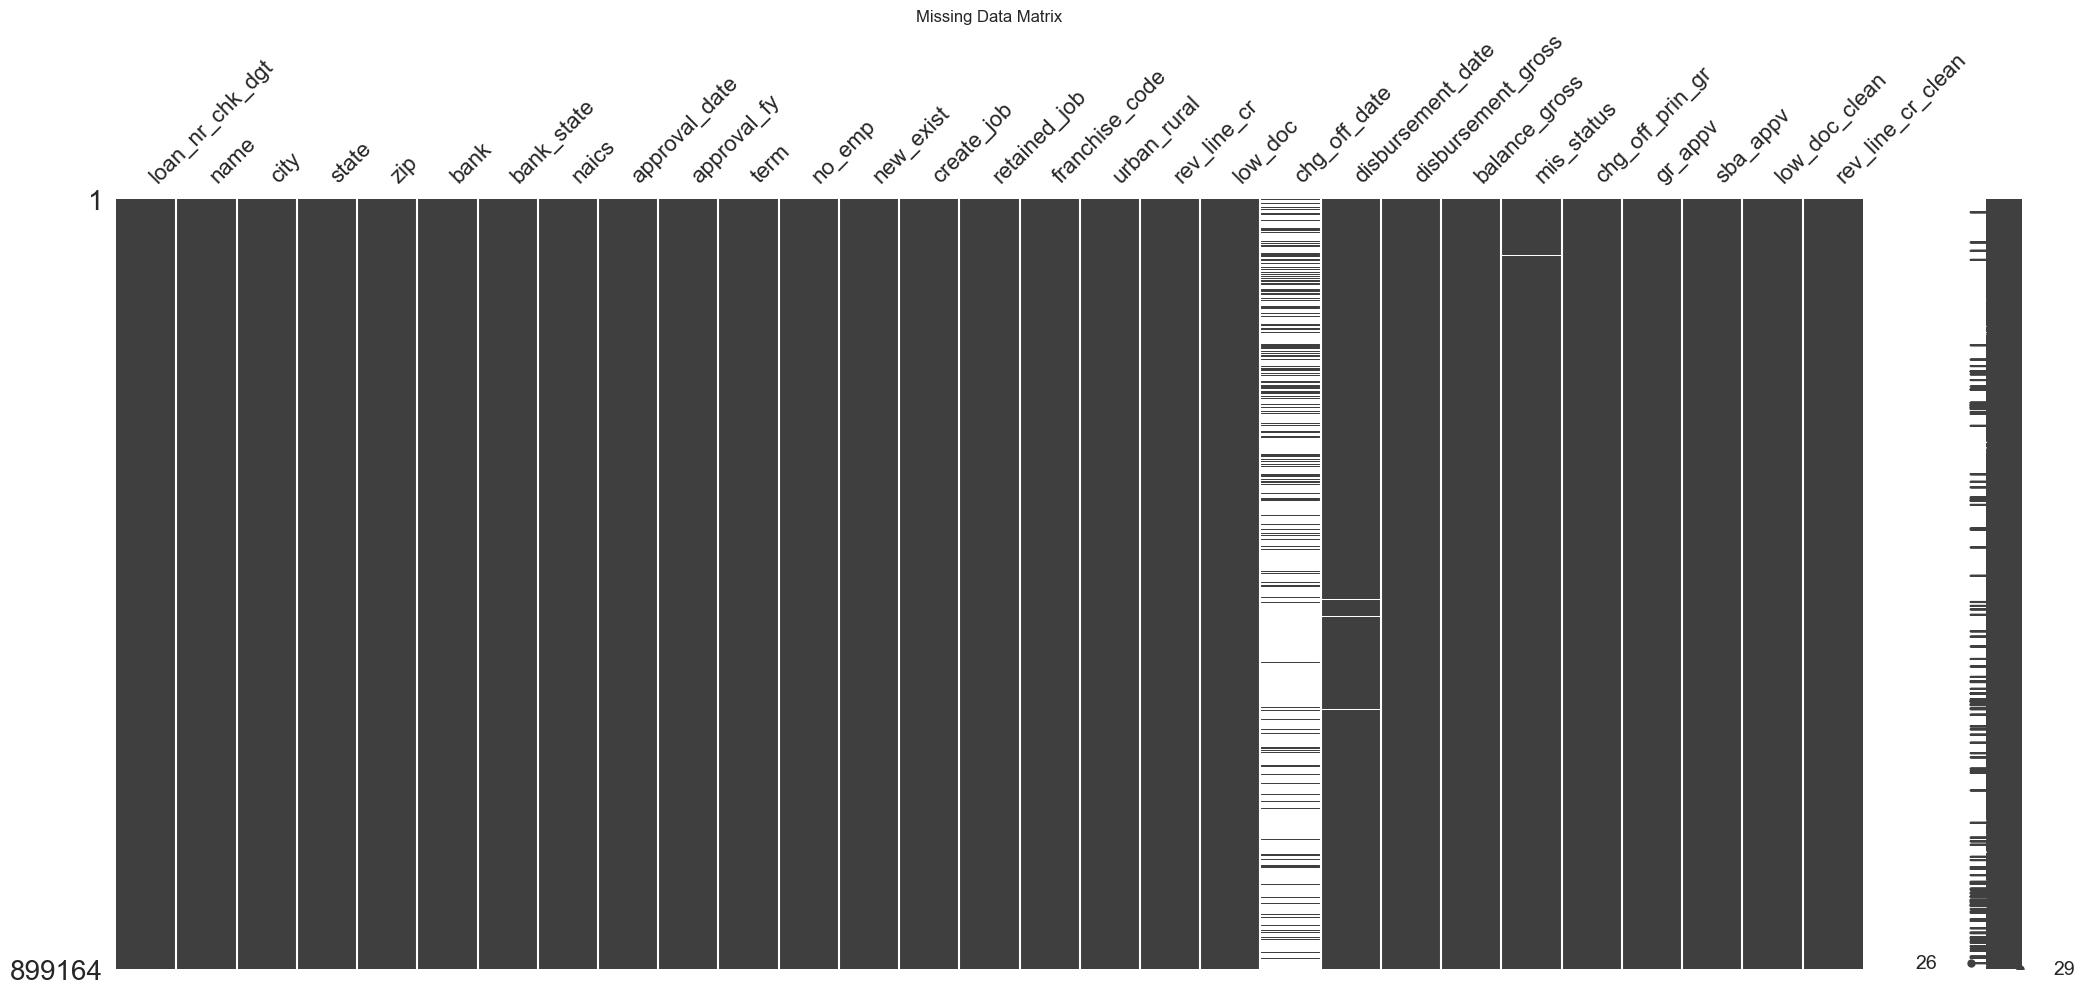

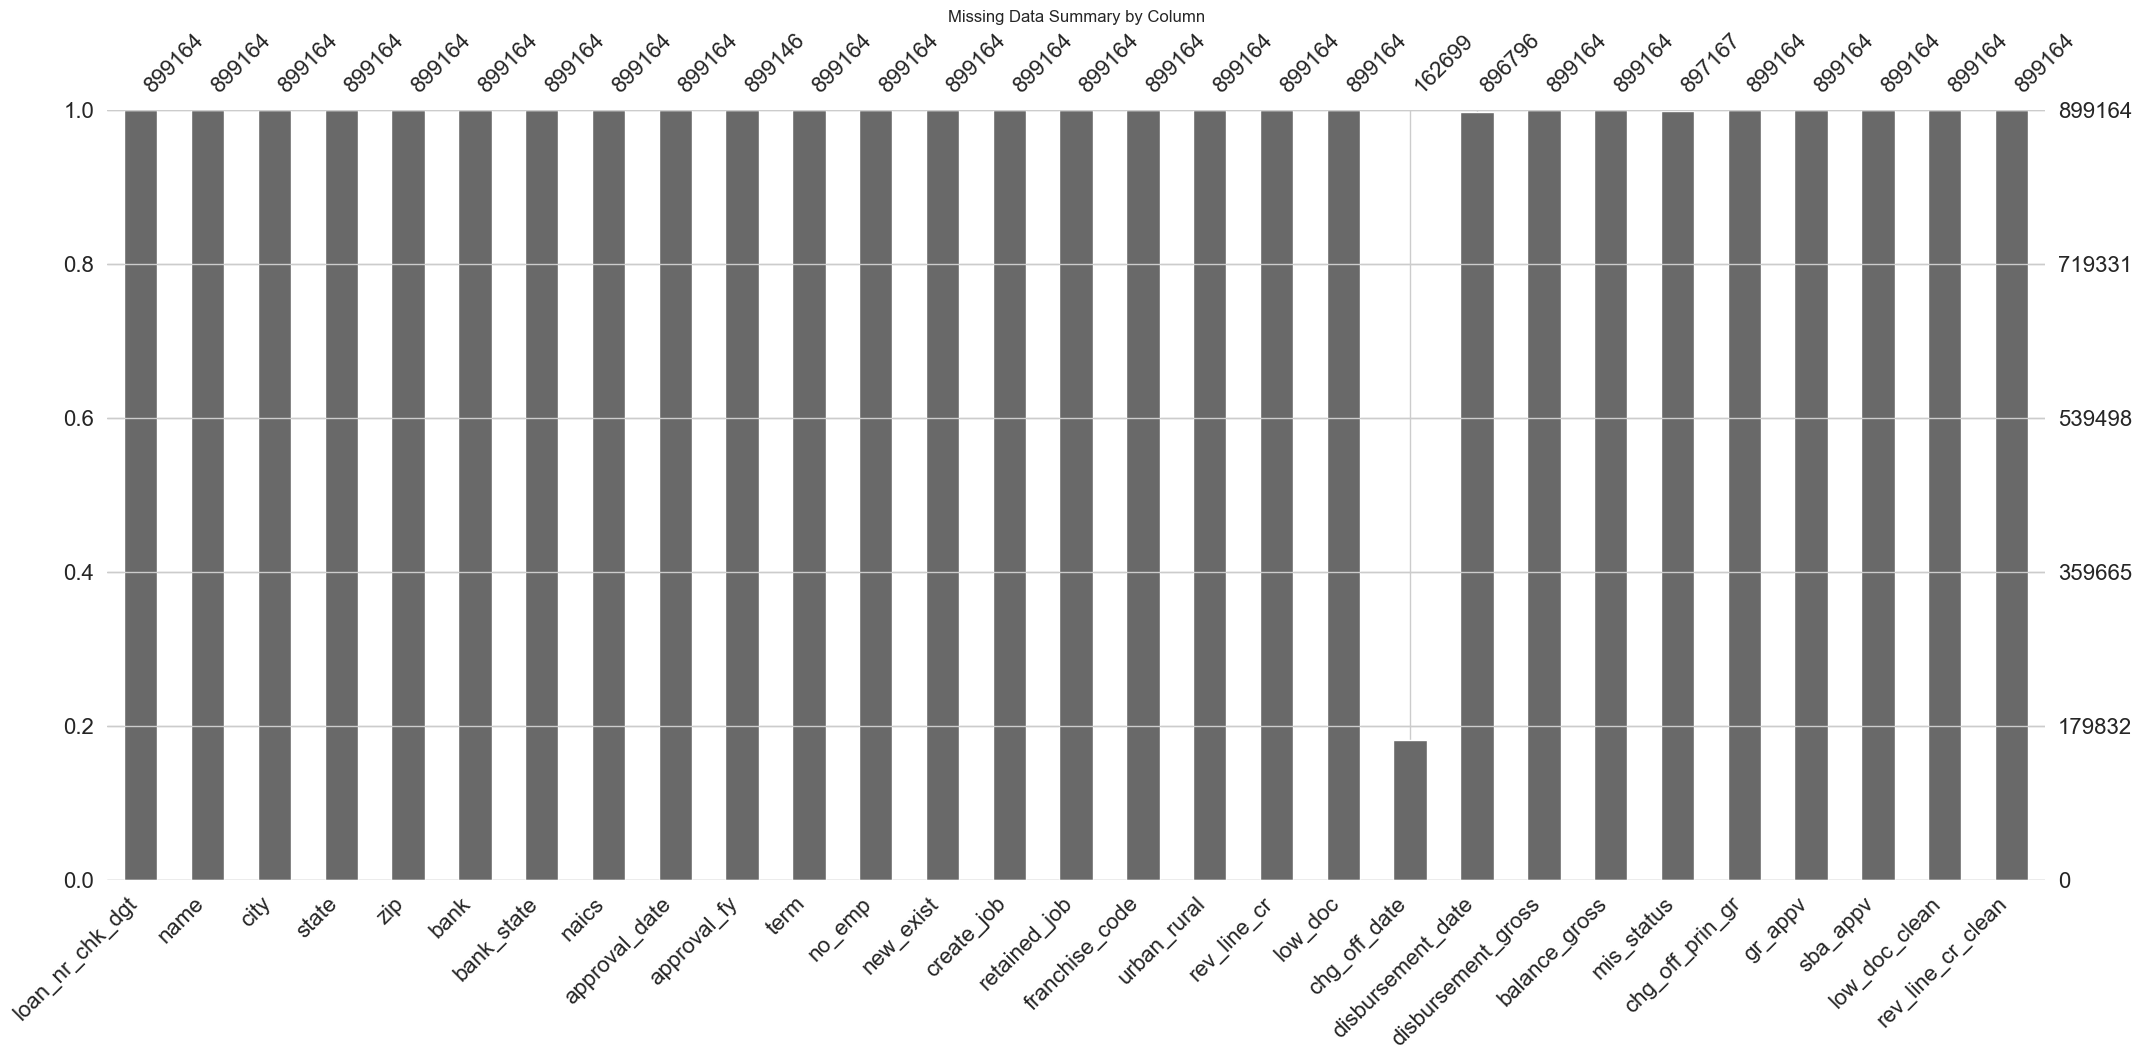

<Figure size 1000x800 with 0 Axes>

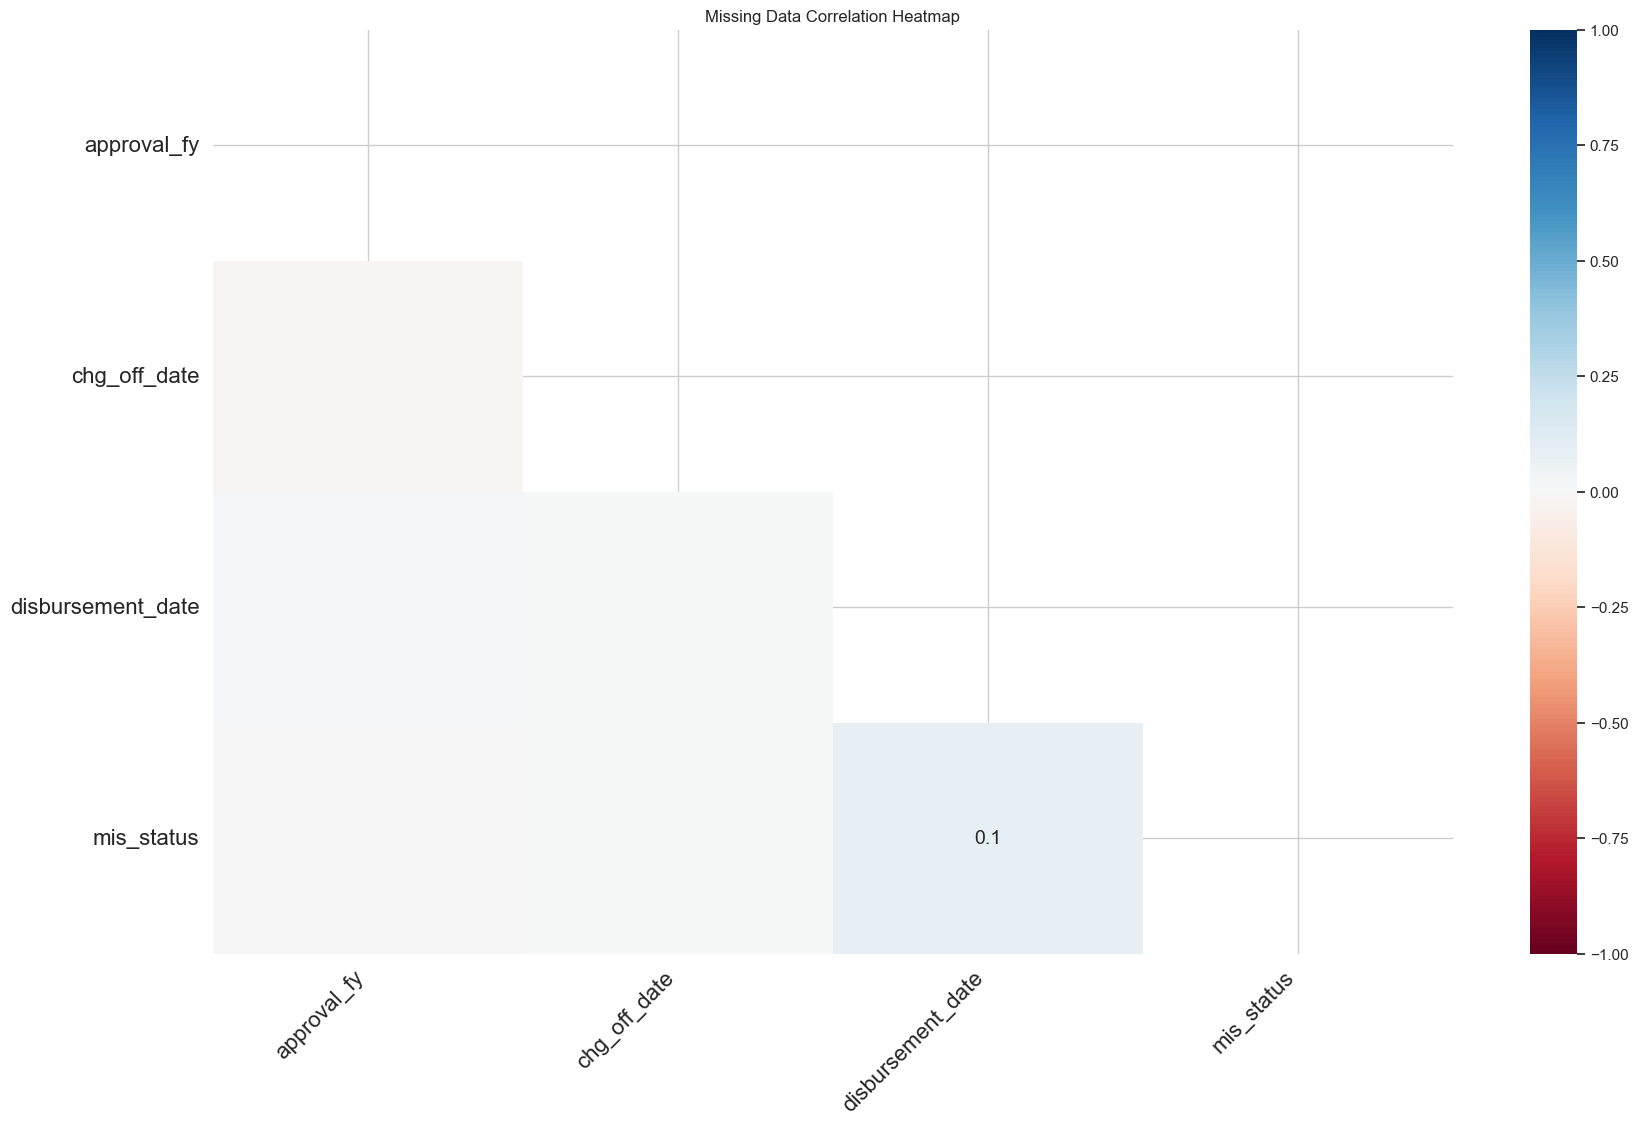

In [11]:
import missingno as msno
from matplotlib.backends.backend_pdf import PdfPages
# === 1. Matrix plot: Shows missing data as lines ===
plt.figure(figsize=(12, 5))
msno.matrix(sba)
plt.title("Missing Data Matrix")
plt.show()

# === 2. Bar plot: Visual summary of missing values per column ===
plt.figure(figsize=(10, 5))
msno.bar(sba)
plt.title("Missing Data Summary by Column")
plt.show()

# === 3. Heatmap: Correlation of missingness between columns ===
plt.figure(figsize=(10, 8))
msno.heatmap(sba)
plt.title("Missing Data Correlation Heatmap")

# Save as PNG

from matplotlib.backends.backend_pdf import PdfPages

# Create a multi-page PDF
with PdfPages("missing_data_overview.pdf") as pdf:
    # 1. Matrix plot
    fig1, ax1 = plt.subplots(figsize=(12, 5))
    msno.matrix(sba, ax=ax1)
    ax1.set_title("Missing Data Matrix", fontsize=14)
    pdf.savefig(fig1, bbox_inches="tight")  # Save this figure to PDF
    plt.close(fig1)

    # 2. Bar plot
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    msno.bar(sba, ax=ax2)
    ax2.set_title("Missing Data Summary by Column", fontsize=14)
    pdf.savefig(fig2, bbox_inches="tight")
    plt.close(fig2)

    # 3. Heatmap
    fig3, ax3 = plt.subplots(figsize=(10, 8))
    msno.heatmap(sba, ax=ax3)
    ax3.set_title("Missing Data Correlation Heatmap", fontsize=14)
    pdf.savefig(fig3, bbox_inches="tight")
    plt.close(fig3)

plt.show()

The missing data matrix visually confirmed the extent of missingness, particularly the high percentage of missing values in the chg_off_date column, as previously identified in the missing values summary table. The heatmap helped to identify if missingness in one column was related to missingness in another. In this case, the heatmap indicates some correlation in missingness between chg_off_date and disbursement_date, suggesting that if one of these dates is missing, the other is also likely to be missing.

### Exploratory data analytics
#### Descriptive Analysis

**Steps**
- Check target Variable Distribution
- Numerical Feature Distributions by Loan Status
- Visualizing Loan Status by Documentation Type
- Loan Default Rate Over Time
- Trends in Loan Approvals by Outcome
- Loan Default Rate by State (All States)
- Loan Default Patterns Across Categorical Features
- Interaction of State and Urban/Rural Classification on Default Rate
- Numerical Feature Distribution
- Geographical Analysis
- Overview of NAICS distribution
- Loan Term Buckets Analysis
- Loan Default Rate Analysis by Term Length
- Default Rate Analysis by SBA Approval Amount
- Loan Default Rate Analysis by Number of Employees.

#### Target Variable Distribution

Class distribution:
             Count  Percentage (%)
mis_status                        
P I F       739609           82.26
CHGOFF      157558           17.52
NaN           1997            0.22


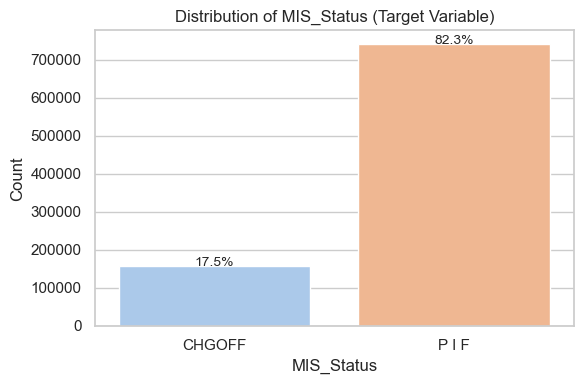

In [12]:
print("Class distribution:")

# Get counts and percentages
value_counts = sba['mis_status'].value_counts(dropna=False)
percentages = 100 * value_counts / len(sba)

# Combine into a single DataFrame for display
class_dist = pd.DataFrame({
    'Count': value_counts,
    'Percentage (%)': percentages.round(2)
})

print(class_dist)

# Plot the class distribution with percentages shown on bars
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=sba, x='mis_status', palette='pastel')

# Add percentage labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    percent = 100 * height / len(sba)
    ax.text(p.get_x() + p.get_width() / 2., height + 500, f'{percent:.1f}%', ha="center", fontsize=10)

plt.title("Distribution of MIS_Status (Target Variable)")
plt.xlabel("MIS_Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### Numerical Feature Distributions by Loan Status.
The selected features include:
- `term`.
- `no_emp`.
- `create_job`.
- `retained_job`.  
- `disbursement_gross`.

These boxplots help detect differences in central tendency, spread, and outliers between the two loan outcome groups. Patterns observed here may provide early insights into which numerical features are potentially predictive of loan default.

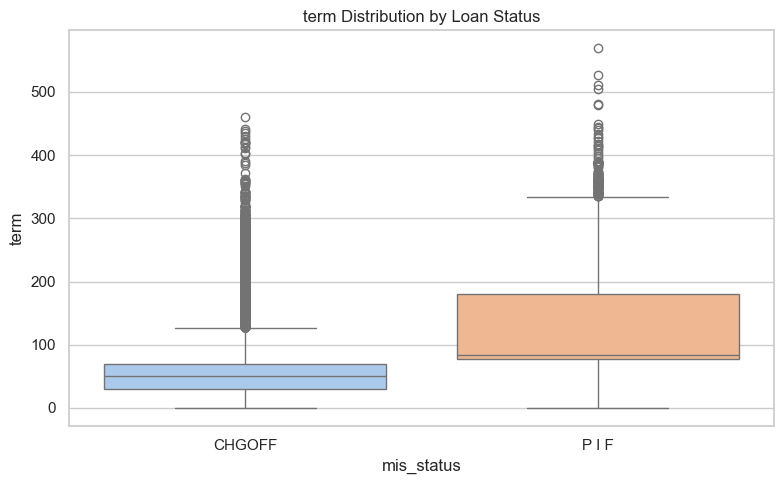

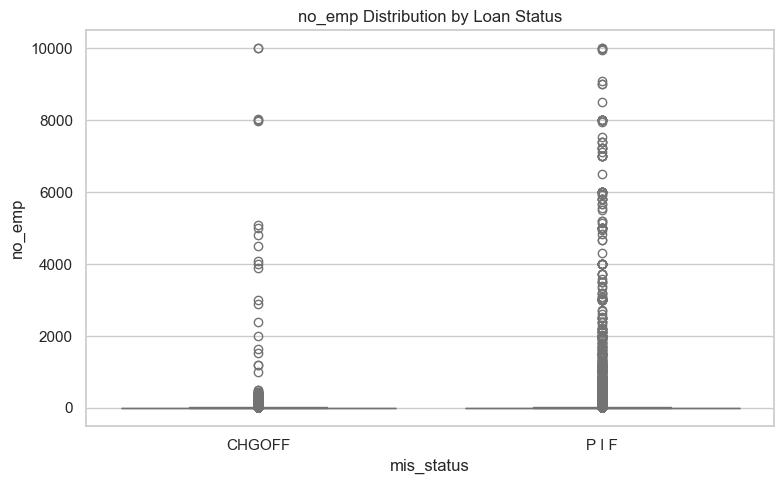

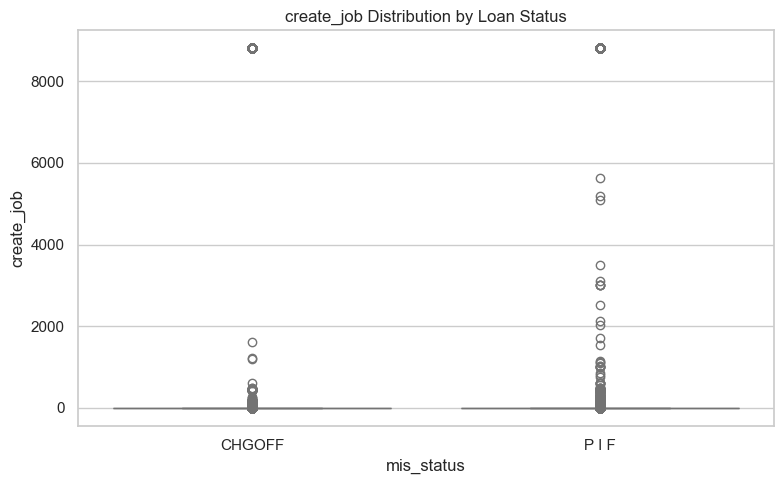

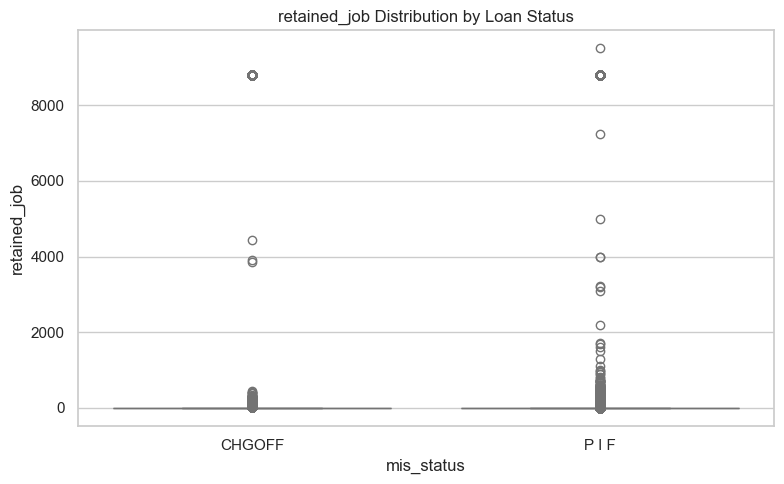

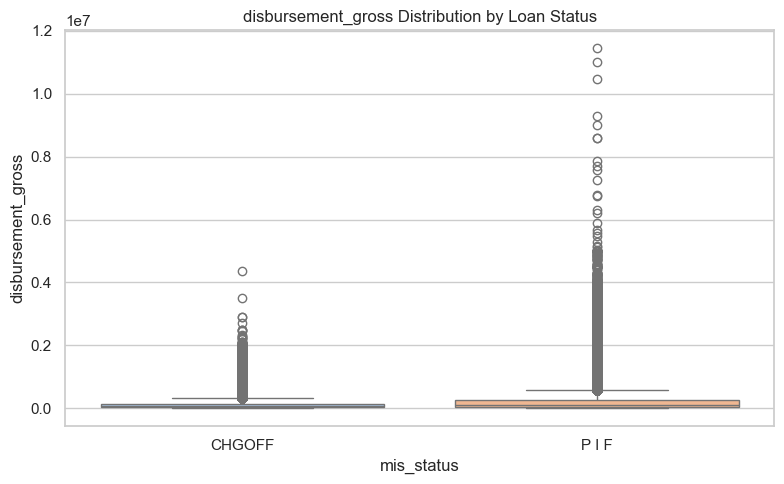

In [13]:
num_features = ['term', 'no_emp', 'create_job', 'retained_job', 'disbursement_gross']

for col in num_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=sba, x='mis_status', y=col, palette='pastel')
    plt.title(f'{col} Distribution by Loan Status')
    plt.tight_layout()
    plt.show()

#### **Visualizing Loan Status by Documentation Type**

The count plot below shows the **distribution of loan outcomes (`mis_status`) across different categories of the `low_doc` variable**.

This visualization complements the earlier cross-tab by giving us a sense of **how frequent each documentation category is**, and how **loan status (Paid in Full vs. Charged Off)** varies across them.

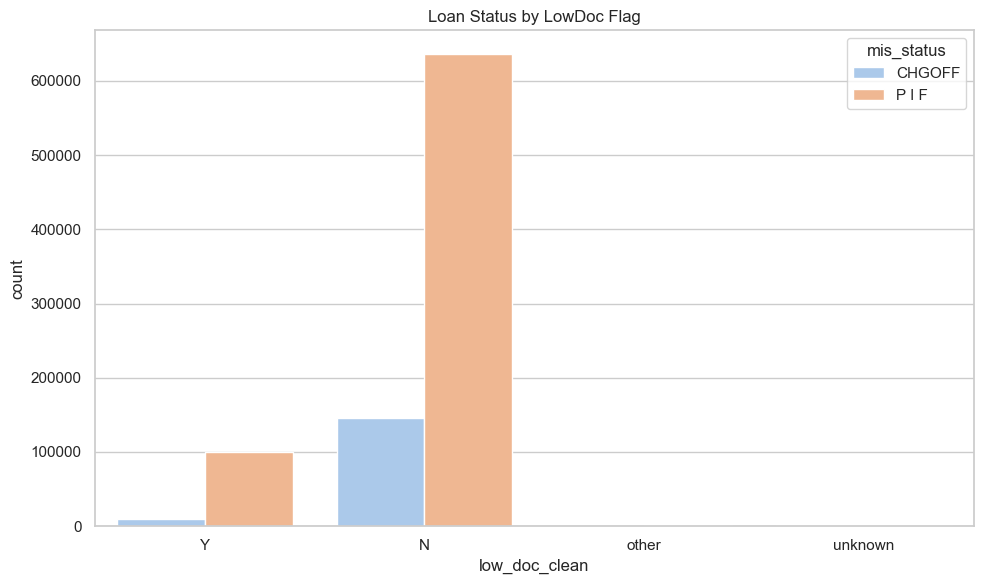

In [14]:
sns.countplot(data=sba, x='low_doc_clean', hue='mis_status', palette='pastel')
plt.title("Loan Status by LowDoc Flag")
plt.tight_layout()
plt.show()

#### Loan Default Rate Over Time

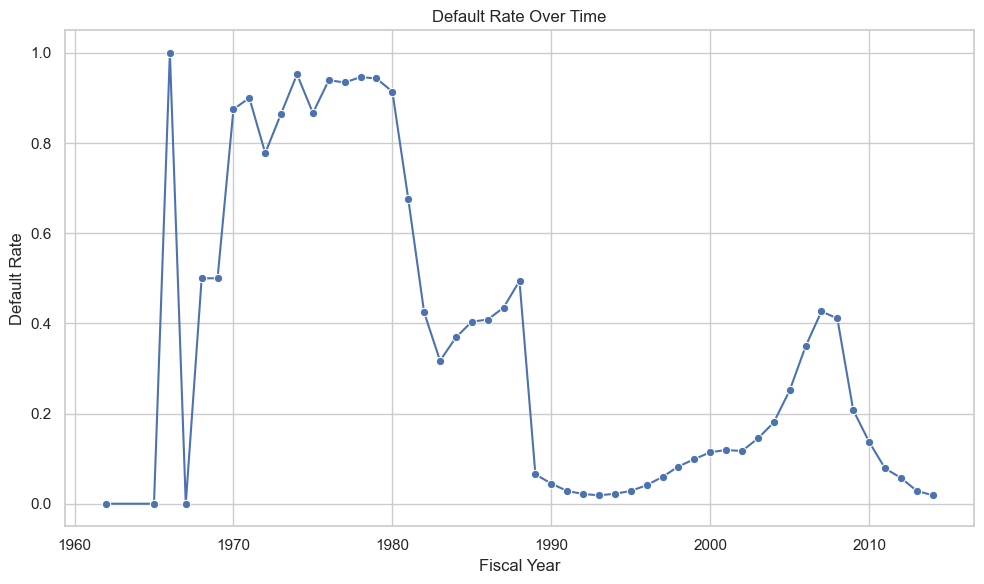

In [15]:
# Step 1: Create a binary 'defaulted' column based on 'mis_status'
# 1 = defaulted (CHGOFF), 0 = not defaulted (e.g., P I F, etc.)
sba['defaulted'] = (sba['mis_status'] == 'CHGOFF').astype(int)

# Step 2: Calculate default rate per fiscal year
# Group by fiscal year (approval_fy) and compute mean of 'defaulted' (i.e., default rate)
default_trend = (
    sba.groupby('approval_fy')['defaulted']
    .mean()                                # This gives proportion of defaults per year
    .reset_index()
    .rename(columns={'defaulted': 'default_rate'})  # Rename column for clarity
)

# Step 3: Plot the trend of default rate over time
sns.lineplot(data=default_trend, x='approval_fy', y='default_rate', marker='o')
plt.title("Default Rate Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

#### Trends in Loan Approvals by Outcome

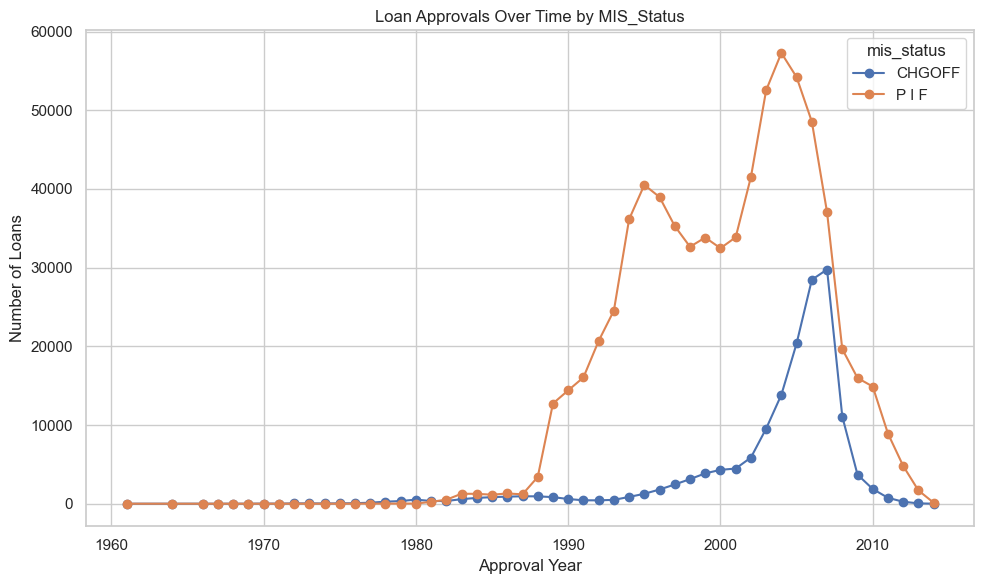

In [16]:
from datetime import datetime

# Step 0: Fix potential century errors in approval_date using approval_fy
def fix_century_issue(row):
    try:
        ad = row['approval_date']
        fy = int(row['approval_fy'])

        if pd.isna(ad) or pd.isna(fy):
            return ad

        # If the approval_date is in the 2000s but FY is in the 1900s, assume century mismatch
        if ad.year > 2000 and fy < 2000:
            year_suffix = ad.year % 100
            fy_prefix = fy // 100
            corrected_year = fy_prefix * 100 + year_suffix
            return pd.Timestamp(datetime(corrected_year, ad.month, ad.day))

        return ad

    except:
        return pd.NaT

# Apply the correction
sba['approval_date'] = sba.apply(fix_century_issue, axis=1)

# Step 1: Extract the year from the corrected approval_date
sba['approval_year'] = sba['approval_date'].dt.year

# Step 2: Group data by approval_year and mis_status, then count the number of records
yearly_counts = sba.groupby(['approval_year', 'mis_status']).size()

# Step 3: Reshape the grouped data to make each mis_status a separate column
yearly_counts = yearly_counts.unstack().fillna(0)

# Step 4: Plot the results as a line chart
yearly_counts.plot(kind='line', marker='o')
plt.title("Loan Approvals Over Time by MIS_Status")
plt.xlabel("Approval Year")
plt.ylabel("Number of Loans")
plt.tight_layout()
plt.show()

#### Loan Default Rate by State (All States)

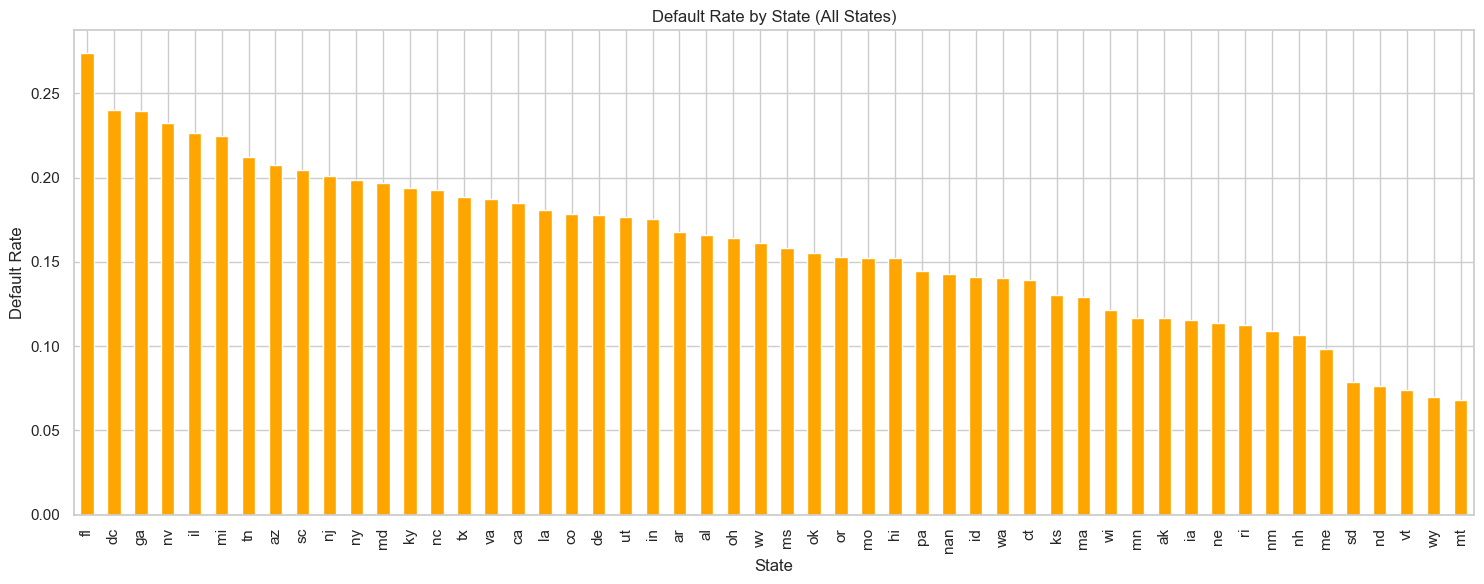

In [17]:
default_by_state = (
    sba.groupby('state')['defaulted']     # Group by state
    .mean()                               # Calculate default rate (mean of 1s and 0s)
    .sort_values(ascending=False)         # Sort by default rate
)

# Step 4–9: Plot all states
plt.figure(figsize=(15, 6))                           # Wider figure for many states
default_by_state.plot(kind='bar', color='orange')    # Bar chart of all states
plt.title("Default Rate by State (All States)")       # Title
plt.ylabel("Default Rate")                            # Y-axis label
plt.xlabel("State")                                   # X-axis label
plt.xticks(rotation=90)                               # Rotate state labels
plt.tight_layout()                                    # Prevent label cutoffs
plt.show()

The analysis of the default rate by state reveals significant variations in loan performance across different geographical locations. The bar plot visually represents these differences, with the states sorted in descending order of their default rates. Looking at the sorted data, Florida (FL) has the highest default rate among all states at approximately 28%. This high default rate in Florida could be influenced by various factors, including regional economic conditions, industry concentrations, or specific lending practices within the state.

#### Loan Default Patterns Across Categorical Features


=== Crosstab of low_doc_clean vs Defaulted ===
               Not Defaulted  Defaulted
low_doc_clean                          
N                      81.37      18.63
Y                      91.02       8.98
other                  72.63      27.37
unknown                61.35      38.65


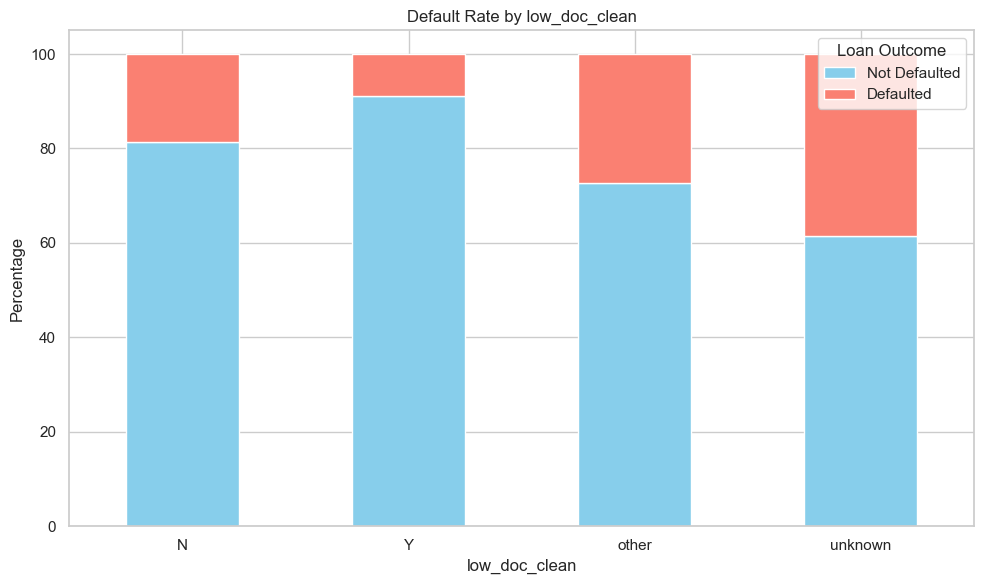


=== Crosstab of rev_line_cr_clean vs Defaulted ===
                   Not Defaulted  Defaulted
rev_line_cr_clean                          
N                          85.26      14.74
Y                          74.68      25.32
other                      57.18      42.82
unknown                    97.55       2.45


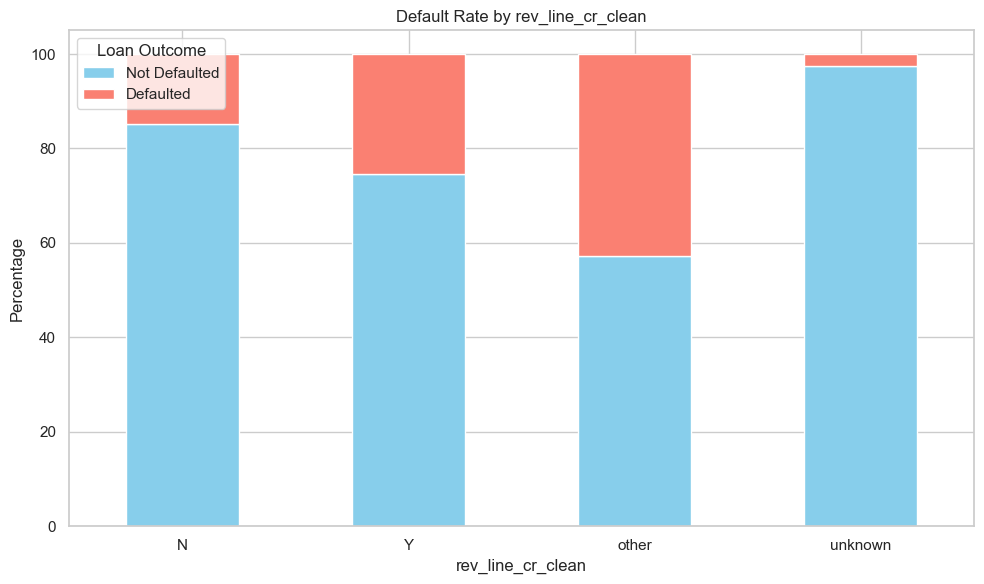


=== Crosstab of urban_rural vs Defaulted ===
             Not Defaulted  Defaulted
urban_rural                          
Rural                81.29      18.71
Undefined            92.89       7.11
Urban                75.59      24.41


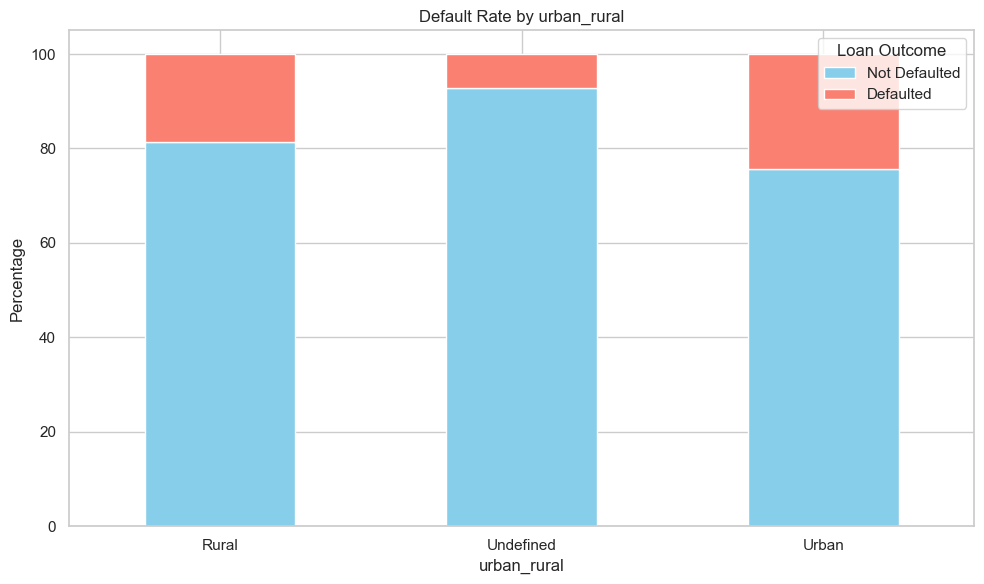


=== Crosstab of new_exist vs Defaulted ===
           Not Defaulted  Defaulted
new_exist                          
Existing           82.92      17.08
New                81.29      18.71
Unknown            93.42       6.58


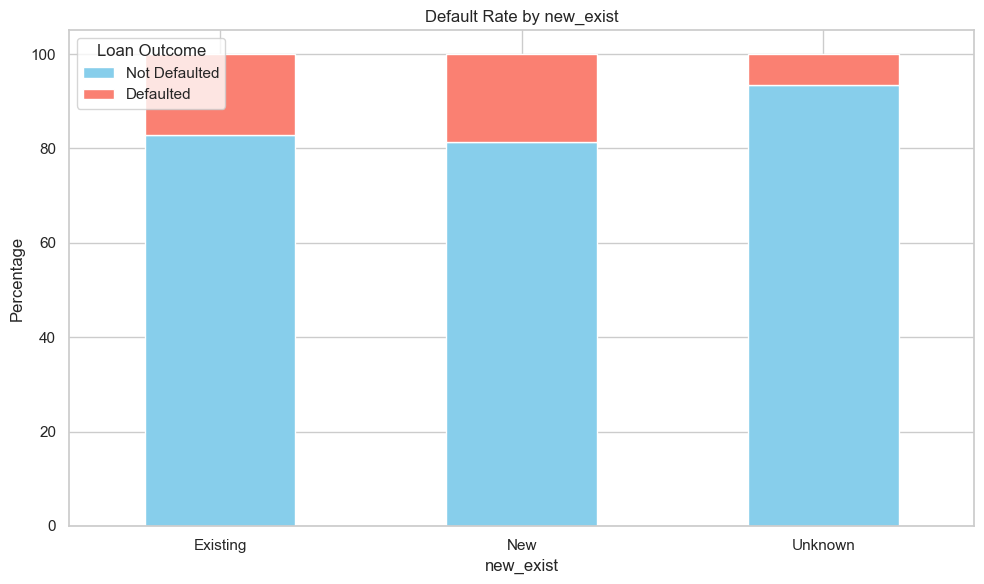

In [18]:
# List of categorical features to analyze
cat_features = ['low_doc_clean', 'rev_line_cr_clean', 'urban_rural', 'new_exist']

# Loop through each feature and plot its relationship with 'defaulted'
for feature in cat_features:
    print(f"\n=== Crosstab of {feature} vs Defaulted ===")

    # Create crosstab (row percentages)
    ctab = pd.crosstab(sba[feature], sba['defaulted'], normalize='index') * 100
    ctab.columns = ['Not Defaulted', 'Defaulted']
    print(ctab.round(2))  # Display as percentages

    # Plot the percentage bar chart
    ctab.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
    plt.title(f'Default Rate by {feature}')
    plt.ylabel('Percentage')
    plt.xlabel(feature)
    plt.legend(title='Loan Outcome')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

The analysis of low_doc_clean against loan outcome shows a clear distinction in default rates across categories. Loans with 'low_doc_clean' status of 'other' and 'unknown' exhibit notably higher default percentages compared to loans marked as 'N'  or 'Y' . This suggests that loans with non-standard or unclassified low documentation status are associated with significantly higher risk of charge-off. This finding emphasizes the importance of accurate and complete information regarding the low documentation status for assessing loan risk.

Examining the relationship between rev_line_cr_clean and loan outcome reveals that loans with a 'Y' (Yes) for revolving line of credit have a higher default rate) compared to those with 'N' (No). Interestingly, loans categorized as 'other' for rev_line_cr_clean show the highest default rate. The 'unknown' category for revolving line of credit had a very low default rate), which might warrant further investigation to understand the nature of these loans or if 'unknown' in this context implies a different status than truly missing. These findings suggest that the presence and specific status of a revolving line of credit are important indicators of loan risk.

The analysis of urban_rural against loan outcome indicates differences in default rates based on the location type. Loans in 'Urban' areas have the highest default at 24%, followed by 'Rural' at18%. Loans with an 'Undefined' urban_rural status show a significantly lower default of 7%. This suggests that geographical location, particularly the distinction between urban and rural areas, plays a role in loan performance, with urban loans appearing to carry a higher default risk in this dataset.

Looking at the relationship between new_exist (New or Existing business) and loan outcome, both 'Existing' and 'New' businesses have almost similar defaultively18% and 17%). However, loans with an 'Unknown' status for new_exist show a considerably lower defaul.6.58%. While 'New' businesses have a slightly higher propensity for default than 'Existing' ones, the 'Unknown' category stands out with a much lower default rate, which could be due to how these cases are recorded or represent a distinct group of loans with different risk characteristics.

#### Interaction of State and Urban/Rural Classification on Default Rate

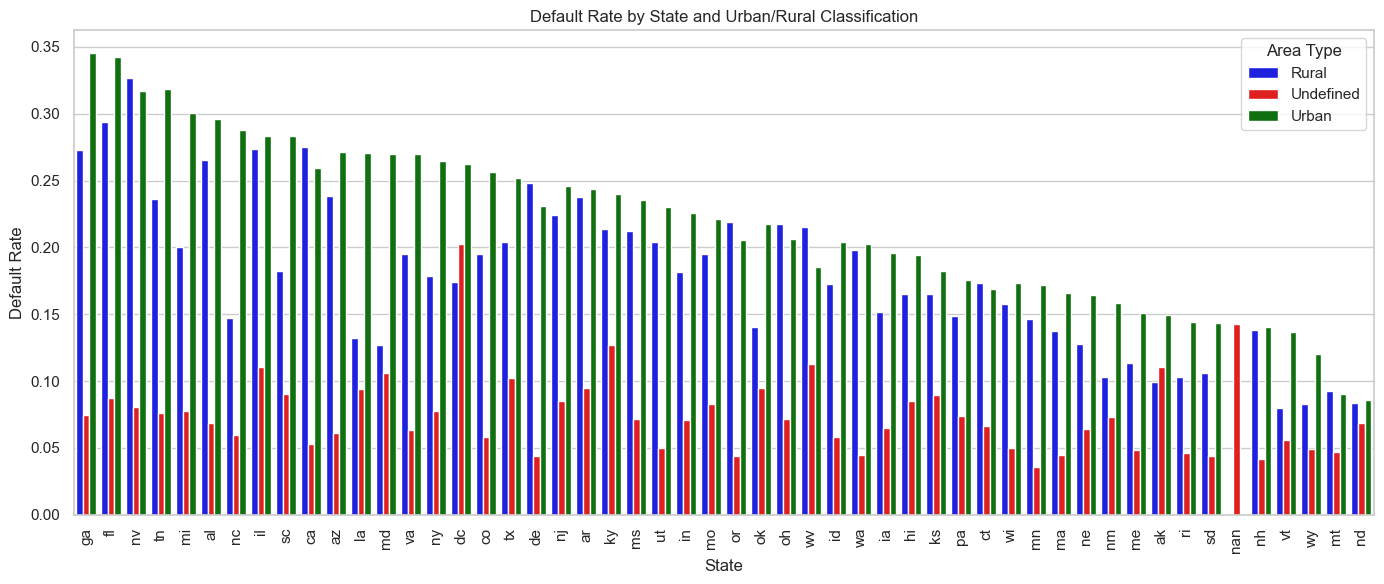

In [19]:
# Step 1: Group by state and urban/rural, calculate mean default rate
default_by_state_urban = (
    sba.groupby(['state', 'urban_rural'])['defaulted']
    .mean()
    .reset_index()
    .rename(columns={'defaulted': 'default_rate'})
)

# Step 2: Sort by default rate (optional)
default_by_state_urban = default_by_state_urban.sort_values(by='default_rate', ascending=False)

# Step 3: Define custom color palette
color_palette = {
    'Urban': 'green',
    'Rural': 'blue',
    'Undefined': 'red'  # in case this category exists
}

# Step 4: Plot
plt.figure(figsize=(14, 6))
sns.barplot(
    data=default_by_state_urban,
    x='state',
    y='default_rate',
    hue='urban_rural',
    palette=color_palette
)

# Step 5: Final plot formatting
plt.title("Default Rate by State and Urban/Rural Classification")
plt.xlabel("State")
plt.ylabel("Default Rate")
plt.xticks(rotation=90)
plt.legend(title='Area Type')
plt.tight_layout()
plt.show()

The grouped bar plot visualizing the default rate by state and urban/rural classification provides a more granular look at geographical loan performance. We can observe that default rates vary not only by state but also significantly between urban and rural areas within those states. For instance, while **Florida (FL)** had the highest overall default rate, the plot shows that Urban areas in Florida have a particularly high default rate (~34%). Similarly, Urban areas in **Georgia (GA)** also exhibit a high default rate (~34%). In contrast, some states show lower default rates in both urban and rural areas. The 'Undefined' category also shows varying default rates across states. This detailed breakdown highlights the importance of considering both state and urban/rural factors when assessing loan risk and could inform more localized risk modeling or strategies.

#### Visualize loan counts by state to check regional trends.

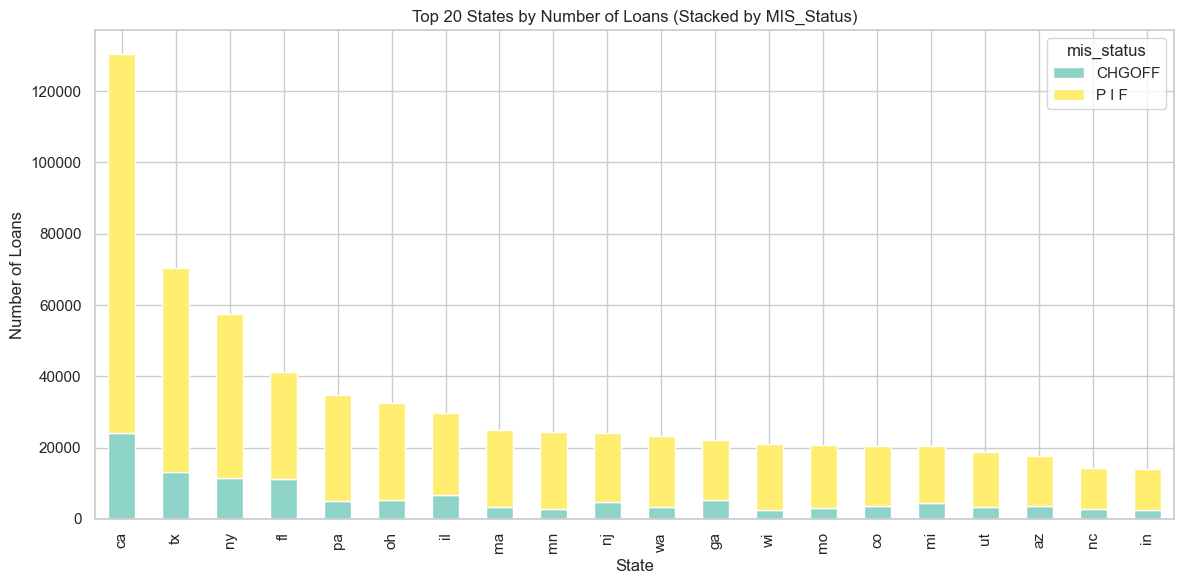

In [20]:
# Group by state and target status
state_counts = sba.groupby(['state', 'mis_status']).size().unstack().fillna(0)

# Plot top 20 states by total loan count
top_states = state_counts.sum(axis=1).sort_values(ascending=False).head(20)
top_states_data = state_counts.loc[top_states.index]

# Bar chart
top_states_data.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set3')
plt.title("Top 20 States by Number of Loans (Stacked by MIS_Status)")
plt.xlabel("State")
plt.ylabel("Number of Loans")
plt.tight_layout()
plt.show()

#### Overview of NAICS distribution (top industries by count)

Top 20 NAICS Codes by Loan Count:
naics
0         201948
722110     27989
722211     19448
811111     14585
621210     14048
624410     10111
812112      9230
561730      8935
621310      8733
812320      7894
541110      7088
445310      6850
621111      6723
721110      6703
447110      6621
713940      6588
811121      6261
451110      6025
453220      6003
484110      5844
Name: count, dtype: int64


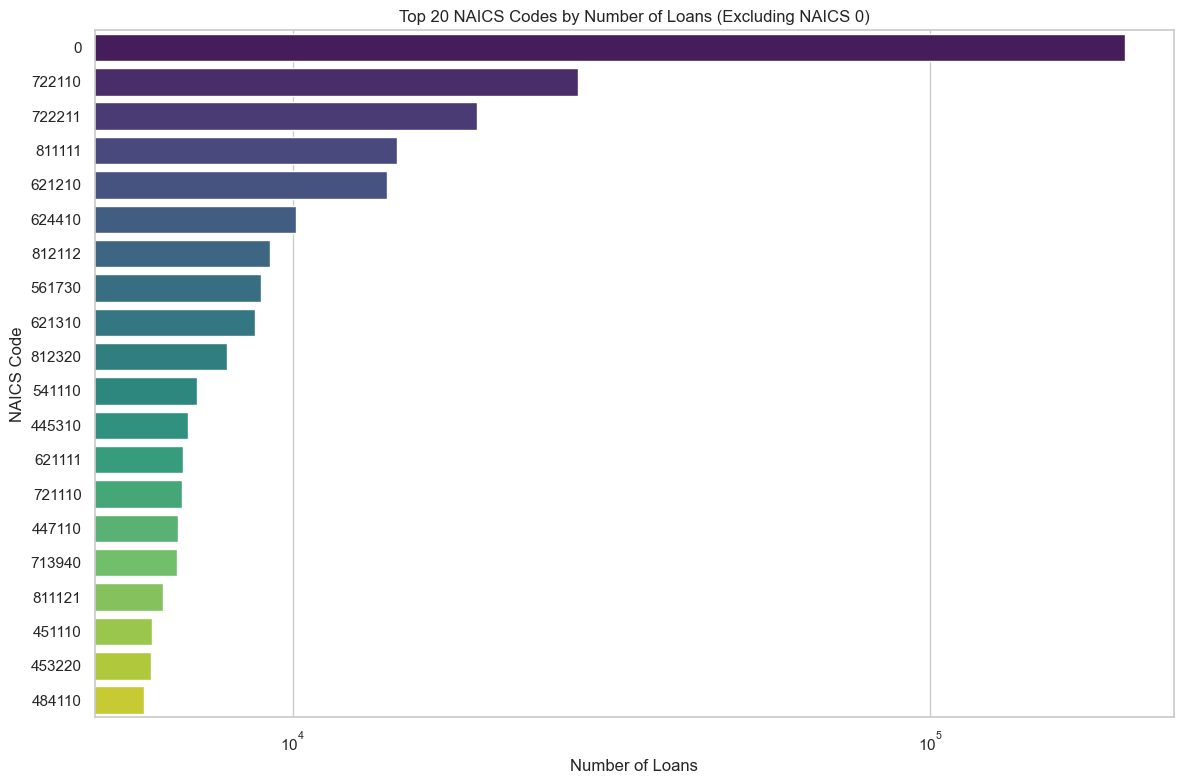

In [21]:
# Count loans per NAICS code, sort descending
naics_counts = sba['naics'].value_counts().head(20)
print("Top 20 NAICS Codes by Loan Count:")
print(naics_counts)

# Plot top 20 NAICS loan counts
plt.figure(figsize=(12, 8))
sns.barplot(
    x=naics_counts[naics_counts.index != '0'].values, 
    y=naics_counts[naics_counts.index != '0'].index.astype(str), 
    palette='viridis'
)
plt.title('Top 20 NAICS Codes by Number of Loans (Excluding NAICS 0)')
plt.xlabel('Number of Loans')
plt.ylabel('NAICS Code')
plt.xscale('log')  # Log scale to better spread out bars
plt.tight_layout()
plt.show()

#### Default Rate Analysis by SBA Approval Amount
Loans with smaller SBA approval amounts (up to $25k) show the highest default rate at around 29(percent) , even though they represent the largest loan count. As loan amounts increase, the default rate generally decreases, dropping to about 7% for loans over $1 million. This indicates that larger SBA loans tend to have lower default risk compared to smaller loans.

#### Loan Term Buckets Analysis
This code categorizes loans into four term buckets based on their duration in months. It then calculates and summarizes the average loan amount, default rate, and loan count for each bucket. Finally, it visualizes these statistics with bar charts, showing how loan size and default risk vary across different loan term ranges.

      term_bucket  avg_loan_amount  default_rate  loan_count
0      <60 months    105741.926126      0.381555      265359
1   60-120 months    145281.416195      0.110066      418030
2  121-180 months    289024.778473      0.081676       48766
3     >180 months    468705.436687      0.033580      166199


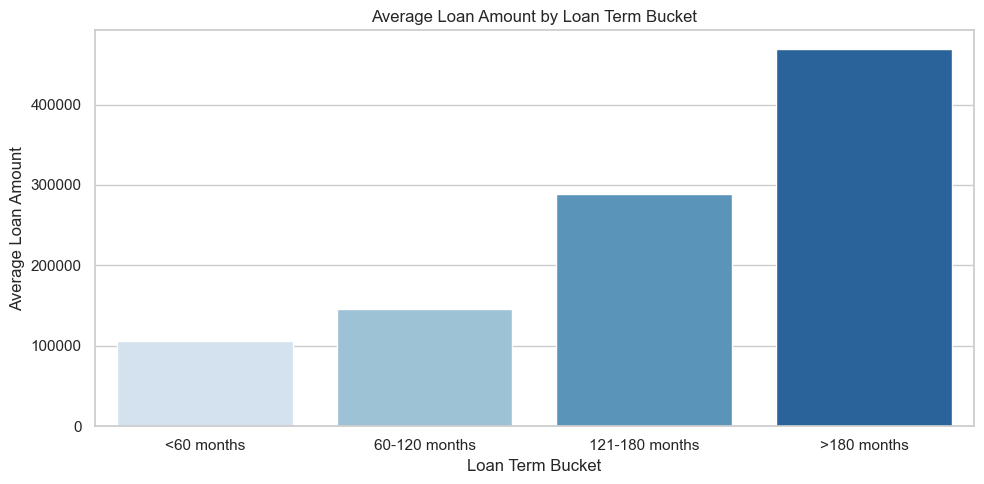

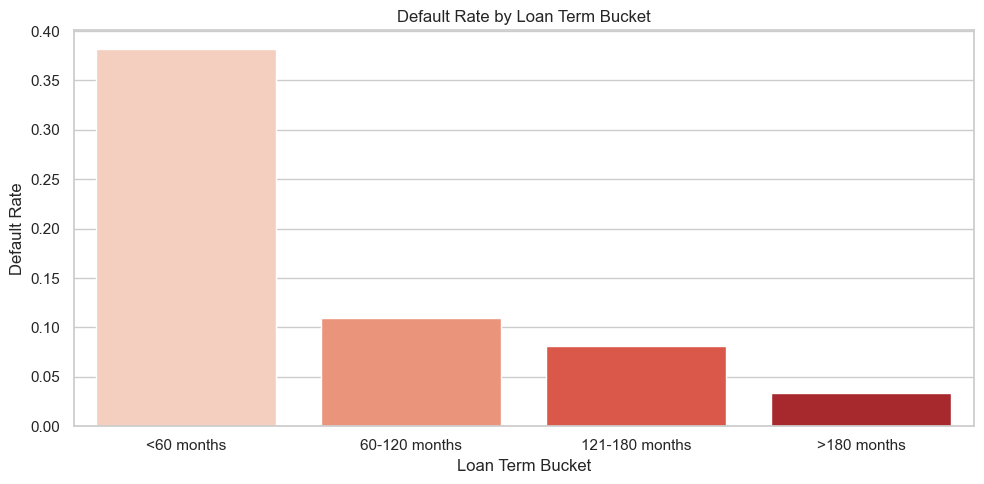

In [22]:
# Create loan term buckets (example: <60, 60-120, 121-180, >180 months)
bins = [0, 60, 120, 180, sba['term'].max()]
labels = ['<60 months', '60-120 months', '121-180 months', '>180 months']
sba['term_bucket'] = pd.cut(sba['term'], bins=bins, labels=labels, right=True)

# Group by term bucket and calculate stats
term_summary = sba.groupby('term_bucket').agg(
    avg_loan_amount=('disbursement_gross', 'mean'),
    default_rate=('defaulted', 'mean'),
    loan_count=('defaulted', 'count')
).reset_index()

print(term_summary)

# Plot average loan amount by term bucket
plt.figure(figsize=(10,5))
sns.barplot(data=term_summary, x='term_bucket', y='avg_loan_amount', palette='Blues')
plt.title('Average Loan Amount by Loan Term Bucket')
plt.xlabel('Loan Term Bucket')
plt.ylabel('Average Loan Amount')
plt.tight_layout()
plt.show()

# Plot default rate by term bucket
plt.figure(figsize=(10,5))
sns.barplot(data=term_summary, x='term_bucket', y='default_rate', palette='Reds')
plt.title('Default Rate by Loan Term Bucket')
plt.xlabel('Loan Term Bucket')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

  loan_amount_bin  default_rate  loan_count
0          $0-25k      0.290809      292869
1        $25k-50k      0.184201      128631
2       $50k-100k      0.108303      134779
3      $100k-250k      0.113344      181165
4      $250k-500k      0.090948       95956
5        $500k-1M      0.073736       56987
6             >1M      0.072348        8777


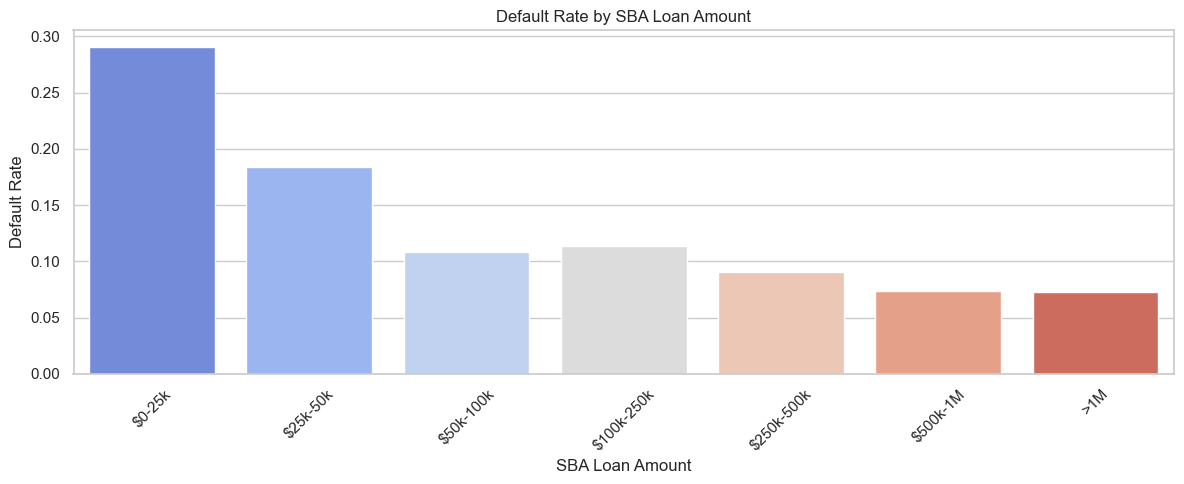

In [23]:
# Define bins for SBA approval amount
amount_bins = [0, 25000, 50000, 100000, 250000, 500000, 1_000_000, sba['sba_appv'].max()]
amount_labels = ['$0-25k', '$25k-50k', '$50k-100k', '$100k-250k', '$250k-500k', '$500k-1M', '>1M']
sba['loan_amount_bin'] = pd.cut(sba['sba_appv'], bins=amount_bins, labels=amount_labels, right=True)

# Calculate default rate and counts per loan amount bin
amount_summary = sba.groupby('loan_amount_bin').agg(
    default_rate=('defaulted', 'mean'),
    loan_count=('defaulted', 'count')
).reset_index()

print(amount_summary)

# Plot default rate by loan amount bin
plt.figure(figsize=(12,5))
sns.barplot(data=amount_summary, x='loan_amount_bin', y='default_rate', palette='coolwarm')
plt.title('Default Rate by SBA Loan Amount')
plt.xlabel('SBA Loan Amount')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Loan Default Rate Analysis by Number of Employees
This block of code groups loans based on the number of employees in the borrowing business by creating employee count bins. It then calculates the average loan default rate within each employee group to analyze how default risk varies with business size. Finally, it visualizes these default rates across employee count groups using a bar plot, helping to identify any relationship between company size and loan default likelihood. From the visualization below we can see that the highest default rate is with the businesses with 0-5 employees with a default rate of almost 0.225 and lowes between 500-1000 employees somewhere between 0.0125 default rate.

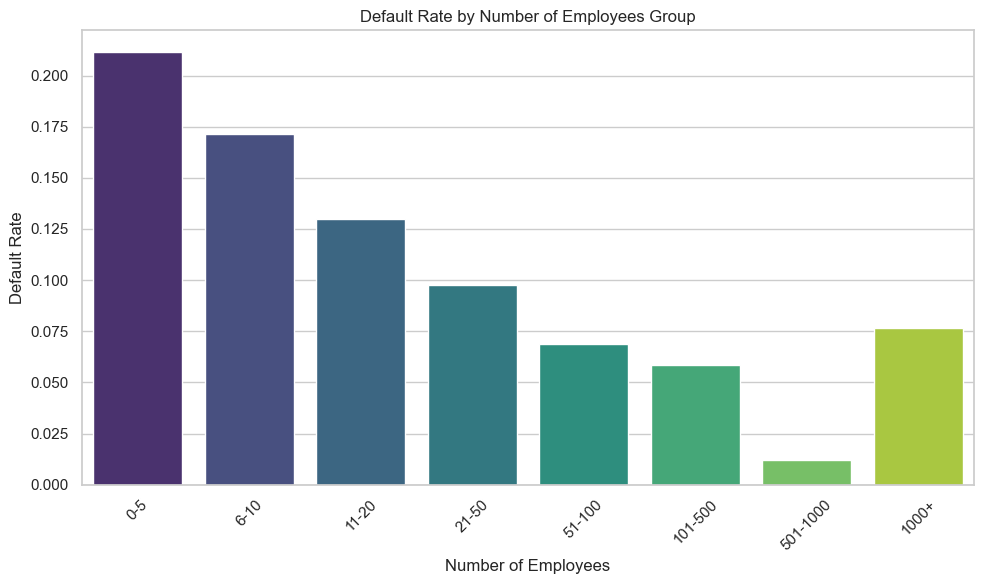

In [24]:
### Define bins and labels for no_emp (number of employees)
emp_bins = [0, 5, 10, 20, 50, 100, 500, 1000, 10000]
emp_labels = ['0-5', '6-10', '11-20', '21-50', '51-100', '101-500', '501-1000', '1000+']

# Create a binned column for no_emp
sba['no_emp_group'] = pd.cut(sba['no_emp'], bins=emp_bins, labels=emp_labels, right=False, include_lowest=True)

# Calculate default rate by employment group
default_by_emp = (
    sba.groupby('no_emp_group')['defaulted']
    .mean()
    .reset_index()
    .rename(columns={'defaulted': 'default_rate'})
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=default_by_emp, x='no_emp_group', y='default_rate', palette='viridis')
plt.title('Default Rate by Number of Employees Group')
plt.xlabel('Number of Employees')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Loan Default Rate Analysis by Number of Employees.
This block of code groups loans based on the number of employees in the borrowing business by creating employee count bins. It then calculates the average loan default rate within each employee group to analyze how default risk varies with business size. Finally, it visualizes these default rates across employee count groups using a bar plot, helping to identify any relationship between company size and loan default likelihood. From the visualization below we can see that the highest default rate is with the businesses with 0-5 employees with a default rate of almost 0.225 and lowes between 500-1000 employees somewhere between 0.0125 default rate.

### Diagnostic Analysis

#### Loan Documentation vs. Loan Outcome

We used a **cross-tabulation** to examine how loan documentation levels (`low_doc`) relate to loan performance (`mis_status`). The table below shows the **percentage of loans paid in full (P I F)** versus **charged off (CHGOFF)** for each documentation category.

In [25]:
pd.crosstab(sba['low_doc_clean'], sba['mis_status'], normalize='index') * 100

mis_status,CHGOFF,P I F
low_doc_clean,,
N,18.674687,81.325313
Y,8.989580,91.010420
other,27.409326,72.590674
unknown,38.712180,61.287820


#### Correlation Analysis of Numeric Features
In this step, we examine the **correlation matrix** of selected numeric variables in the dataset to better understand how these features relate to one another and to the target variable `defaulted`.

Correlation Matrix:

                    term  no_emp  create_job  retained_job  \
term                1.00    0.05        0.03          0.02   
no_emp              0.05    1.00        0.01          0.02   
create_job          0.03    0.01        1.00          0.99   
retained_job        0.02    0.02        0.99          1.00   
disbursement_gross  0.47    0.09        0.01          0.01   
gr_appv             0.50    0.09        0.01          0.01   
sba_appv            0.52    0.09        0.01          0.01   
defaulted          -0.31   -0.03        0.01          0.01   

                    disbursement_gross  gr_appv  sba_appv  defaulted  
term                              0.47     0.50      0.52      -0.31  
no_emp                            0.09     0.09      0.09      -0.03  
create_job                        0.01     0.01      0.01       0.01  
retained_job                      0.01     0.01      0.01       0.01  
disbursement_gross                1.00     0.97      0.94      -0

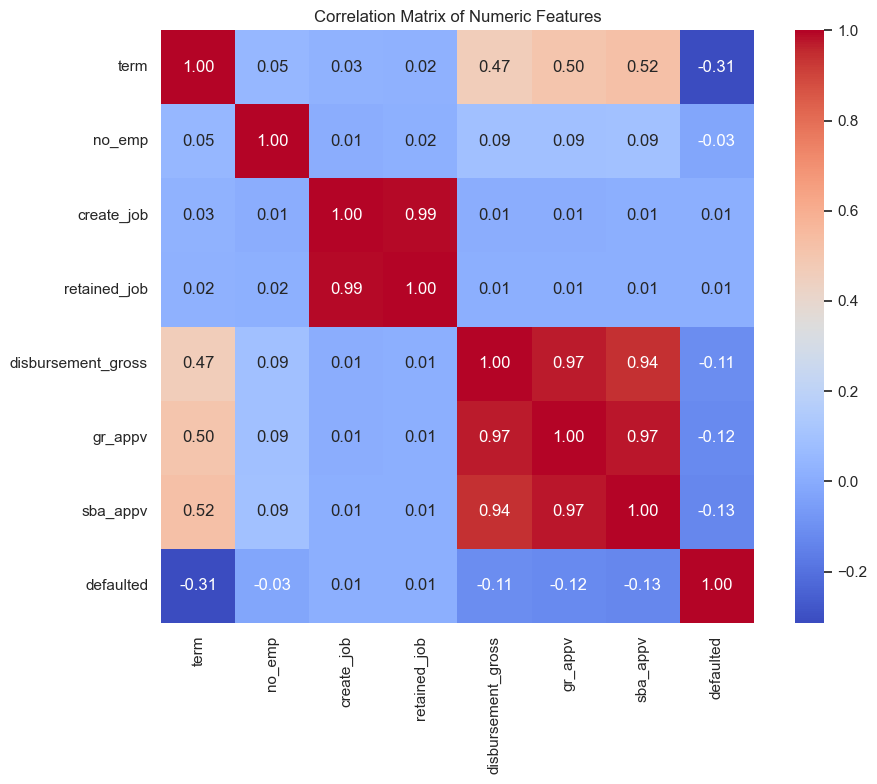

In [26]:
# Select relevant numeric features for correlation analysis
corr_features = ['term', 'no_emp', 'create_job', 'retained_job',
                 'disbursement_gross', 'gr_appv', 'sba_appv', 'defaulted']

# Compute correlation matrix
correlation_matrix = sba[corr_features].corr()

# Print the correlation matrix
print("Correlation Matrix:\n")
print(correlation_matrix.round(2))

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

### Pre-treatment for machine learning
#### Handle Missing Values

In [27]:
missing_counts = sba.isnull().sum()
missing_percent = (missing_counts / len(sba)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percent.round(2)
})

print(missing_summary)

                    Missing Count  Missing Percentage
loan_nr_chk_dgt                 0                0.00
name                            0                0.00
city                            0                0.00
state                           0                0.00
zip                             0                0.00
bank                            0                0.00
bank_state                      0                0.00
naics                           0                0.00
approval_date                  18                0.00
approval_fy                    18                0.00
term                            0                0.00
no_emp                          0                0.00
new_exist                       0                0.00
create_job                      0                0.00
retained_job                    0                0.00
franchise_code                  0                0.00
urban_rural                     0                0.00
rev_line_cr                 

In [28]:
# Drop the entire 'chg_off_date' column
sba = sba.drop(columns=['chg_off_date'])

# Drop all rows with any missing values in the dataframe
sba = sba.dropna()

unwanted = ["Unknown", "Undefined", "other", "others"]
sba= sba[~sba.isin(unwanted).any(axis=1)]

# Drop rows where any column contains 'others' or 'unknown' (case-insensitive)
# This assumes these strings could appear in categorical/text columns
for col in sba.select_dtypes(include='object').columns:
    sba = sba[~sba[col].str.lower().isin(['others', 'unknown'])]

# Reset index after dropping rows
sba = sba.reset_index(drop=True)

In [29]:
# Check if 'chg_off_date' column exists
print("'chg_off_date' column present?:", 'chg_off_date' in sba.columns)

# Check for any remaining missing values
missing_counts = sba.isna().sum()
print("\nMissing values per column after dropping:")
print(missing_counts[missing_counts > 0])

# Check if any 'others' or 'unknown' values remain in object columns
for col in sba.select_dtypes(include='object').columns:
    vals = sba[col].str.lower().unique()
    if 'others' in vals or 'unknown' in vals:
        print(f"\nFound 'others' or 'unknown' in column '{col}':")
        print(sba[sba[col].str.lower().isin(['others', 'unknown'])][col].unique())

'chg_off_date' column present?: False

Missing values per column after dropping:
Series([], dtype: int64)


In [30]:
sba.shape

(552686, 33)

#### Investigating Outliers: Impact of Extreme Number of Employees on Loan Amounts
- In this step, we examine whether loans associated with businesses having an extremely large number of employees also tend to have larger loan amounts. We create two groups:

- extreme_emp: Businesses with a very high number of employees (e.g., above the 99th percentile).

- normal_emp: The rest of the businesses.

We then compare the average loan disbursement (disbursement_gross) or SBA approval amount (sba_appv) between these groups to see if extreme employee count correlates with larger loans. This will allow us to know if the extreme_emp group represents true observations or possible data errors.


     emp_group  avg_disbursement   avg_sba_appv   count
0  extreme_emp     690301.306720  544346.209485    5461
1   normal_emp     190301.671791  133408.650798  547225


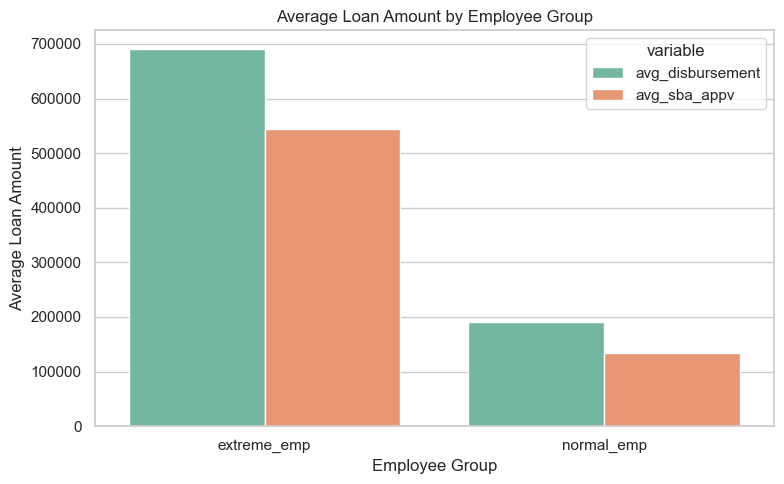

In [31]:
# Determine threshold for extreme employees (e.g., 99th percentile)
extreme_threshold = sba['no_emp'].quantile(0.99)

# Create groups
sba['emp_group'] = ['extreme_emp' if x > extreme_threshold else 'normal_emp' for x in sba['no_emp']]

# Compare average disbursement_gross by group
loan_comparison = sba.groupby('emp_group').agg(
    avg_disbursement=('disbursement_gross', 'mean'),
    avg_sba_appv=('sba_appv', 'mean'),
    count=('disbursement_gross', 'count')
).reset_index()

print(loan_comparison)

# visualize comparison
plt.figure(figsize=(8,5))
sns.barplot(data=loan_comparison.melt(id_vars='emp_group', value_vars=['avg_disbursement', 'avg_sba_appv']),
            x='emp_group', y='value', hue='variable', palette='Set2')
plt.title('Average Loan Amount by Employee Group')
plt.ylabel('Average Loan Amount')
plt.xlabel('Employee Group')
plt.tight_layout()
plt.show()

Because the no_emp variable is highly right-skewed (with a few businesses having extremely large employee counts), we will apply a logarithmic transformation to normalize its distribution. This transformation will reduce the effect of extreme values and help improve the stability and performance of our models by treating the variable more evenly.

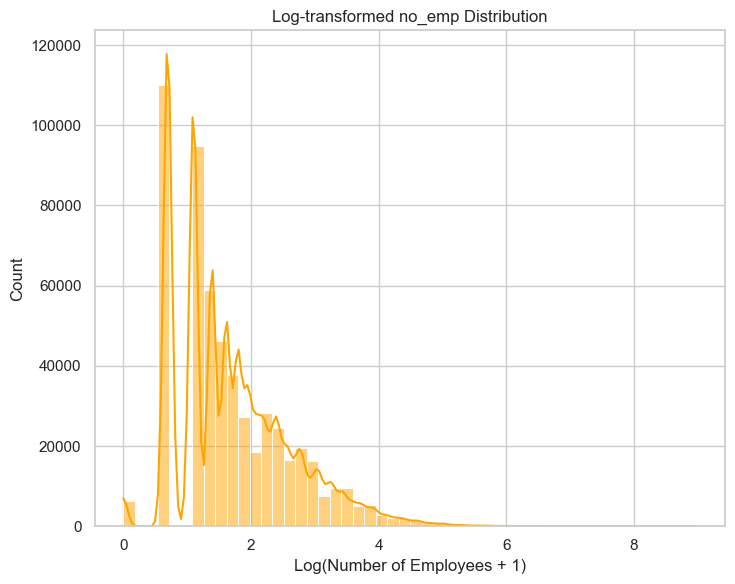

In [32]:
# Add 1 to avoid log(0) issues, then apply log transformation
sba['log_no_emp'] = np.log1p(sba['no_emp'])

# Plot distributions before and after log transform
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 2)
sns.histplot(sba['log_no_emp'], bins=50, kde=True, color='orange')
plt.title('Log-transformed no_emp Distribution')
plt.xlabel('Log(Number of Employees + 1)')

plt.tight_layout()
plt.show()

#### Investigating Extreme Disbursement Amounts for Validity
This step examines whether loans with extremely high disbursement amounts (disbursement_gross) correspond to larger businesses (measured by number of employees, no_emp) and longer loan terms (term). By categorizing loans into extreme and normal disbursement groups and comparing their average employees and loan terms, we assess whether these extreme values reflect true observations or potential data errors. If extreme disbursements align with higher employees and longer terms, they are likely valid and should be retained for modeling.

In [33]:
# Define threshold for extreme disbursement - e.g., 99th percentile
threshold = sba['disbursement_gross'].quantile(0.99)

# Create a new column categorizing disbursement_gross as 'extreme' or 'normal'
sba['disb_group'] = np.where(sba['disbursement_gross'] > threshold, 'extreme_disbursement', 'normal_disbursement')

# Group by the new category and calculate average no_emp and term, and count
disb_summary = (
    sba.groupby('disb_group')
    .agg(
        avg_no_emp = ('no_emp', 'mean'),
        avg_term = ('term', 'mean'),
        count = ('disbursement_gross', 'count')
    )
    .reset_index()
)

print(disb_summary)

             disb_group  avg_no_emp    avg_term   count
0  extreme_disbursement   31.106721  198.241691    5416
1   normal_disbursement    8.635222   96.427098  547270


The analysis compares loans with extremely high disbursement amounts to those with normal disbursement levels. It reveals that loans in the extreme disbursement group are associated with significantly larger businesses, averaging about 32.5 employees compared to 11.2 for the normal group. Additionally, these loans tend to have much longer terms, averaging around 200 months versus 110 months. This indicates that the extreme disbursement values likely represent genuine loans to larger businesses with longer repayment periods, rather than data errors or outliers to be removed.

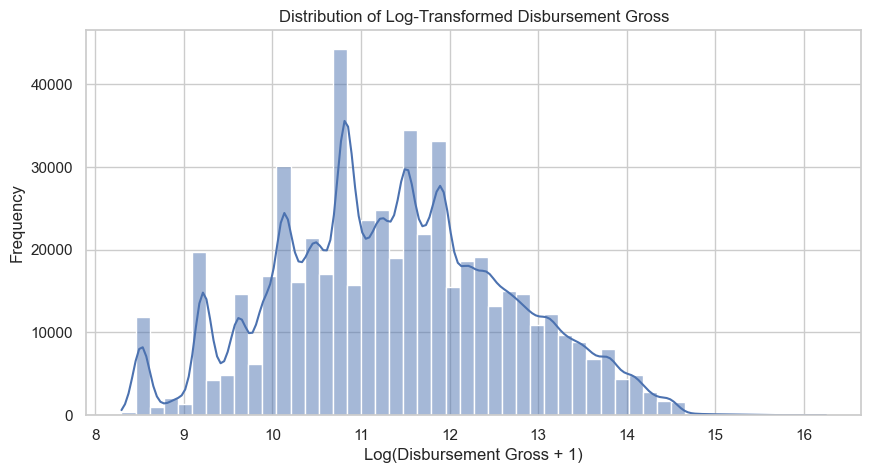

In [34]:
# Add 1 to avoid log(0) issues, then take natural log
sba['log_disbursement_gross'] = np.log1p(sba['disbursement_gross'])

# Check distribution after transformation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(sba['log_disbursement_gross'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Disbursement Gross')
plt.xlabel('Log(Disbursement Gross + 1)')
plt.ylabel('Frequency')
plt.show()

Since disbursement_gross is heavily right-skewed, applying a log transformation (using log1p to handle zero values) helps compress the scale of large values and spreads out smaller values. This makes the distribution more symmetric and better suited for statistical modeling or analysis that assumes normality or less skewness. After transformation, models are often more stable and perform better.

#### Investigating Extreme gr_appv amounts for Validity
This block first flags loans with gr_appv above the 99th percentile as "extreme" and compares their average number of employees (no_emp) and loan term (term) with the rest. If these extreme loans correspond to larger businesses and longer terms, it's a strong indication that the high values are legitimate and not errors. After that, the code applies a logarithmic transformation to gr_appv to reduce skewness, improving model stability and analysis accuracy.

     gr_appv_group  avg_no_emp    avg_term   count
0  extreme_gr_appv   30.512653  209.080521    5216
1   normal_gr_appv    8.649091   96.361026  547470


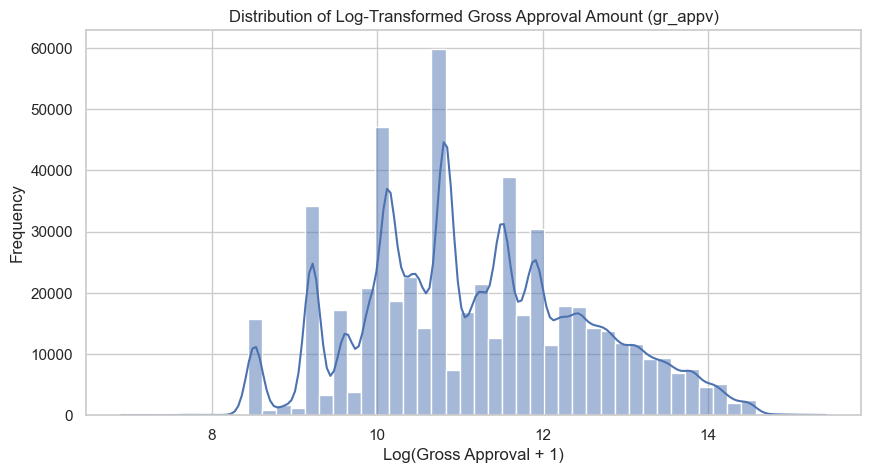

In [35]:
# Define threshold for extreme gr_appv (e.g., 99th percentile)
threshold_gr_appv = sba['gr_appv'].quantile(0.99)

# Create group for extreme vs normal gr_appv
sba['gr_appv_group'] = np.where(sba['gr_appv'] > threshold_gr_appv, 'extreme_gr_appv', 'normal_gr_appv')

# Aggregate mean no_emp and term by gr_appv group
gr_appv_summary = sba.groupby('gr_appv_group').agg(
    avg_no_emp=('no_emp', 'mean'),
    avg_term=('term', 'mean'),
    count=('gr_appv', 'count')
).reset_index()

print(gr_appv_summary)

# If the extreme group has higher no_emp and term, it's likely valid
# Proceed to log transform gr_appv to normalize distribution

sba['log_gr_appv'] = np.log1p(sba['gr_appv'])

# Plot to check distribution after transformation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(sba['log_gr_appv'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Gross Approval Amount (gr_appv)')
plt.xlabel('Log(Gross Approval + 1)')
plt.ylabel('Frequency')
plt.show()

#### retained_job.
This code identifies loans with extremely high values of retained jobs by setting a threshold at the 99th percentile. It then groups the loans into "extreme" and "normal" categories based on this threshold. For each group, it calculates the average number of employees, average loan term, and the count of loans. This helps to determine if the extreme retained job values are likely valid by checking if they correspond to larger businesses or longer loan terms.

In [36]:
# Define threshold for extreme retained_job (e.g., above 99th percentile)
retained_threshold = sba['retained_job'].quantile(0.99)

# Create groups based on retained_job
sba['retained_job_group'] = np.where(
    sba['retained_job'] > retained_threshold, 
    'extreme_retained_job', 
    'normal_retained_job'
)

# Aggregate average no_emp and term by retained_job_group
retained_summary = sba.groupby('retained_job_group').agg(
    avg_no_emp=('no_emp', 'mean'),
    avg_term=('term', 'mean'),
    count=('retained_job', 'count')
).reset_index()

print(retained_summary)


     retained_job_group  avg_no_emp    avg_term   count
0  extreme_retained_job  112.202855  122.587745    5043
1   normal_retained_job    7.903749   97.193108  547643


The analysis compares loans with extremely high numbers of retained jobs (above the 99th percentile) against those with normal retained job counts. The group with extreme retained jobs has a much higher average number of employees (~103 vs. ~10.5) and longer loan terms (~146 months vs. ~111 months). This suggests that the extreme retained job values are likely valid and reflect larger, longer-term loans rather than data errors.

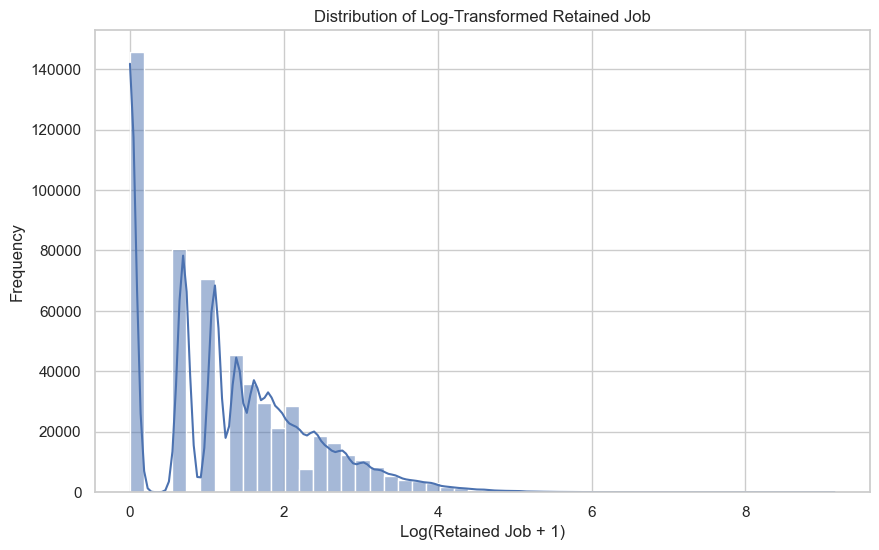

In [37]:
# Apply log transformation with a small constant to avoid log(0)
sba['retained_job_log'] = np.log1p(sba['retained_job'])

# Check the distribution after transformation
plt.figure(figsize=(10,6))
sns.histplot(sba['retained_job_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Retained Job')
plt.xlabel('Log(Retained Job + 1)')
plt.ylabel('Frequency')
plt.show()

In [38]:
missing_counts = sba.isnull().sum()
missing_percent = (missing_counts / len(sba)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percent.round(2)
})

print(missing_summary)

                        Missing Count  Missing Percentage
loan_nr_chk_dgt                     0                 0.0
name                                0                 0.0
city                                0                 0.0
state                               0                 0.0
zip                                 0                 0.0
bank                                0                 0.0
bank_state                          0                 0.0
naics                               0                 0.0
approval_date                       0                 0.0
approval_fy                         0                 0.0
term                                0                 0.0
no_emp                              0                 0.0
new_exist                           0                 0.0
create_job                          0                 0.0
retained_job                        0                 0.0
franchise_code                      0                 0.0
urban_rural   

In [39]:
# Create a deep copy of the dataset
sba1= sba.copy(deep=True)

In [40]:
# 1. Install the category_encoders package
#%pip install category_encoders

# 2. Import it correctly
from category_encoders import TargetEncoder

In [41]:
drop_cols = [
    # Pure identifiers
    'loan_nr_chk_dgt', 'name','city','state','zip','zip'

    # used for eda
    'no_emp_group', 'term_bucket', 'disb_group', 'retained_job_group','loan_size_bin','term_bin','loan_amount_bin', 'emp_group','loan_size_bin','retained_job_group'
     ,'no_emp','retained_job','low_doc','disbursement_gross','chg_off_prin_gr','gr_appv','zip_corrected', 'defaulted','gr_appv_group'
    # Raw numeric columns replaced by log-transformed versions
    'no_emp', 'gr_appv', 'retained_job', 'create_job', 'disbursement_gross','rev_line_cr','no_emp_group','gr_appv_group'
]
sba1 = sba1.drop(columns=[col for col in drop_cols if col in sba1.columns], errors='ignore')

date_cols = ['approval_date', 'chg_off_date', 'disbursement_date','approval_fy','approval_year','approval_date_month ','approval_date_month',
            'approval_date_year', 'approval_date_day', 'disbursement_date_year', 'disbursement_date_month', 'disbursement_date_day']
for col in date_cols:
    if col in sba1.columns and pd.api.types.is_datetime64_any_dtype(sba1[col]):
        sba1[f'{col}_year'] = sba1[col].dt.year
        sba1[f'{col}_month'] = sba1[col].dt.month
        sba1[f'{col}_day'] = sba1[col].dt.day

unwanted = ["unknown", "undefined", "other", "others"]
sba1= sba1[~sba1.isin(unwanted).any(axis=1)]
#  Encoding categorical variables
low_card = ['new_exist','urban_rural','low_doc_clean']
high_card = ['bank','bank_state','naics','franchise_code', 'rev_line_cr_clean']
    

# One-hot encode low-cardinality variables
sba1 = pd.get_dummies(sba1, columns=[col for col in low_card if col in sba1.columns], drop_first=True)

# Target encode high-cardinality variables
target = 'mis_status'
if target in sba1.columns:
    te = TargetEncoder(cols=[col for col in high_card if col in sba1.columns])
    sba1[high_card] = te.fit_transform(sba1[high_card], sba1[target])

#Drop original date columns
sba1 = sba1.drop(columns=date_cols, errors='ignore')

print("Processed dataset shape:", sba1.shape)
print(sba1.head())


Processed dataset shape: (552686, 18)
       bank  bank_state     naics  term  franchise_code  balance_gross  \
0  0.839147    0.890831  0.708221   162        0.559386            0.0   
1  0.804498    0.870894  0.752207   126        0.825292            0.0   
2  0.765950    0.693400  0.871166    83        0.825292            0.0   
3  0.763997    0.776229  0.679637    84        0.825292            0.0   
4  0.831284    0.874223  0.864329    60        0.825292            0.0   

  mis_status  sba_appv  rev_line_cr_clean  log_no_emp  log_disbursement_gross  \
0      P I F  190050.0           0.790179    1.098612               12.442728   
1      P I F  116705.0           0.790179    2.079442               11.829931   
2      P I F   50000.0           0.737821    2.944439               12.991211   
3      P I F   17500.0           0.737821    1.609438               10.848191   
4      P I F   42500.0           0.790179    1.386294               10.819798   

   log_gr_appv  retained_job_l

#### correlation Analysis

Correlation Matrix:

                        bank  bank_state  naics  term  franchise_code  \
bank                    1.00        0.48   0.20  0.28            0.21   
bank_state              0.48        1.00   0.14  0.12            0.14   
naics                   0.20        0.14   1.00  0.23            0.19   
term                    0.28        0.12   0.23  1.00            0.24   
franchise_code          0.21        0.14   0.19  0.24            1.00   
balance_gross           0.00        0.00   0.00  0.00            0.00   
sba_appv                0.27        0.12   0.22  0.57            0.18   
rev_line_cr_clean       0.11        0.12   0.15  0.36            0.17   
log_no_emp              0.19        0.08   0.12  0.19            0.14   
log_disbursement_gross  0.37        0.18   0.25  0.53            0.19   
log_gr_appv             0.39        0.20   0.28  0.58            0.24   
retained_job_log       -0.09       -0.11  -0.03 -0.03           -0.12   

                        balan

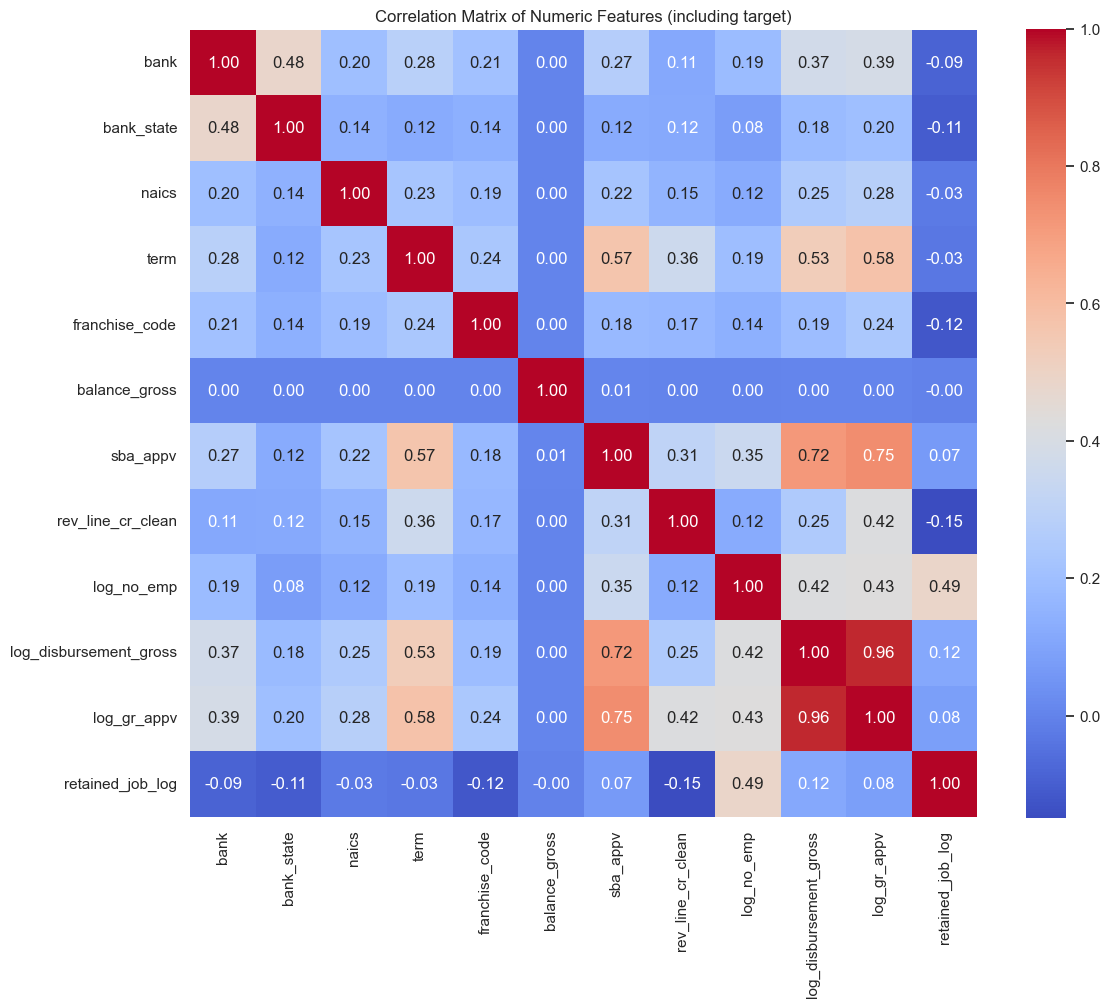

In [42]:
# Select numeric columns only
numeric_cols = sba1.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Compute correlation matrix
corr_matrix = sba1[numeric_cols].corr()

#  Display correlation matrix
print("Correlation Matrix:\n")
print(corr_matrix.round(2))

# Visualize correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Numeric Features (including target)")
plt.tight_layout()
plt.show()

### feature selection

To investigate which **factors influence SBA loan repayment**, we trained a **Random Forest model** to classify loans as “Paid in Full” or “Charged Off.” The model **quantified the relative impact of each feature**, revealing that loan term, bank, industry code (NAICS), and bank state were the most influential. Other variables, such as loan amounts, employee count, and franchise code, also contributed but to a lesser extent. Features like balance and some categorical indicators had minimal effect. This approach highlights the key financial and demographic drivers behind loan performance, offering actionable insights for monitoring and decision-making.

                   Feature  Importance
0                     term    0.494994
1                     bank    0.129231
2                    naics    0.063552
3               bank_state    0.061780
4   log_disbursement_gross    0.049067
5                 sba_appv    0.047425
6              log_gr_appv    0.038994
7           franchise_code    0.028736
8               log_no_emp    0.028504
9         retained_job_log    0.024878
10       rev_line_cr_clean    0.015945
11           new_exist_New    0.007953
12       urban_rural_Urban    0.006113
13         low_doc_clean_Y    0.002819
14           balance_gross    0.000009
15   urban_rural_Undefined    0.000000
16       new_exist_Unknown    0.000000


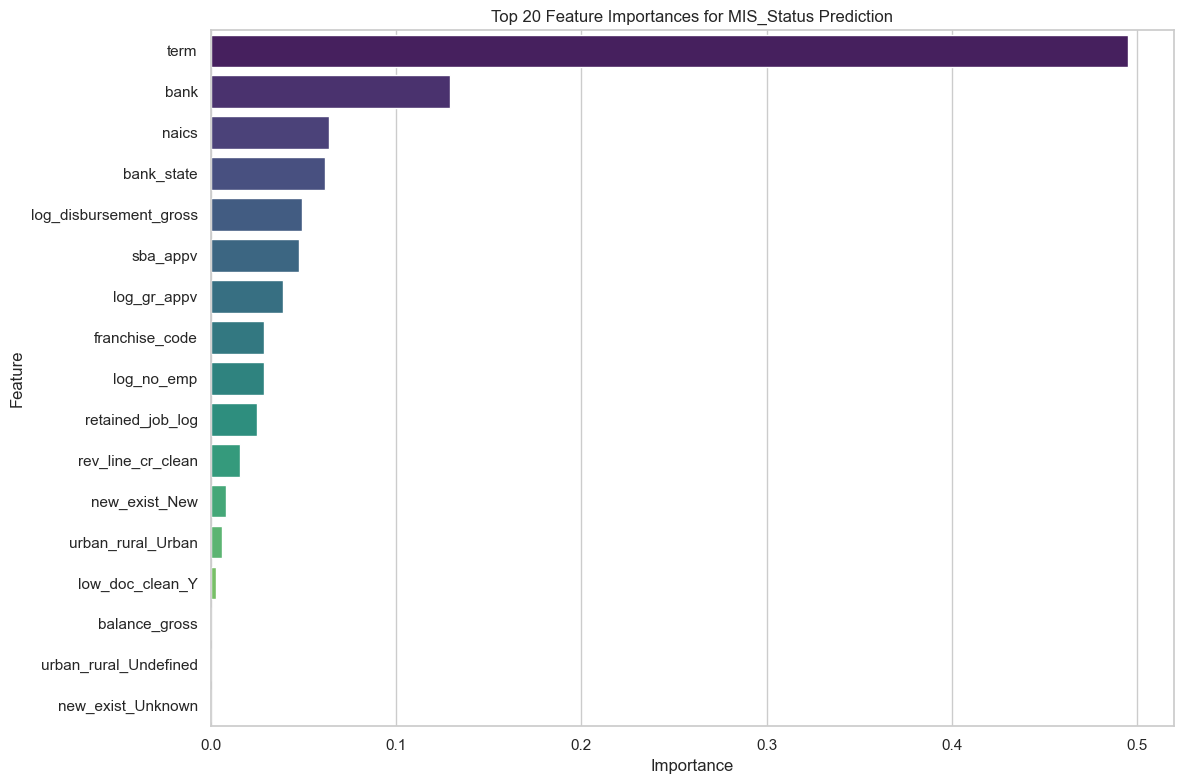

In [43]:
# Step 1: Separate features and target
X = sba1.drop(columns=['mis_status'])  # already numeric / encoded
y = sba1['mis_status'].astype('category').cat.codes  # encode target

# Step 2: Split into train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

# Step 3: Train Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Step 4: Extract feature importances
import pandas as pd
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(feature_importances.head(20))


plt.figure(figsize=(12,8))
sns.barplot(data=feature_importances.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("Top 20 Feature Importances for MIS_Status Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### final dataset using only the top 10 most important features

In [44]:
# Select top 10 important features
top_features = feature_importances['Feature'].head(10).tolist()
print("Top 10 features to use for modeling:", top_features)

# Create a new dataset with only top features
X_top = sba1[top_features]

# Target remains the same
y_top = sba1['mis_status'].astype('category').cat.codes  # encoded target

# Train-test split
#To avoid data leakages we will first split our data into training and testing dataset then do class balancing
from sklearn.model_selection import train_test_split
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y_top, test_size=0.2, random_state=42, stratify=y_top
)

print("Train shape:", X_train_top.shape, "Test shape:", X_test_top.shape)

Top 10 features to use for modeling: ['term', 'bank', 'naics', 'bank_state', 'log_disbursement_gross', 'sba_appv', 'log_gr_appv', 'franchise_code', 'log_no_emp', 'retained_job_log']
Train shape: (442148, 10) Test shape: (110538, 10)


We selected the top 10 features based on their importance scores from the Random Forest model, as these variables contribute most to predicting loan status (mis_status). A new dataset, X_top, was created containing only these features. The target variable was encoded as integers to make it compatible with machine learning algorithms. Finally, the dataset was split into training and testing sets, preparing it for the actual modeling phase.

#### Class balance

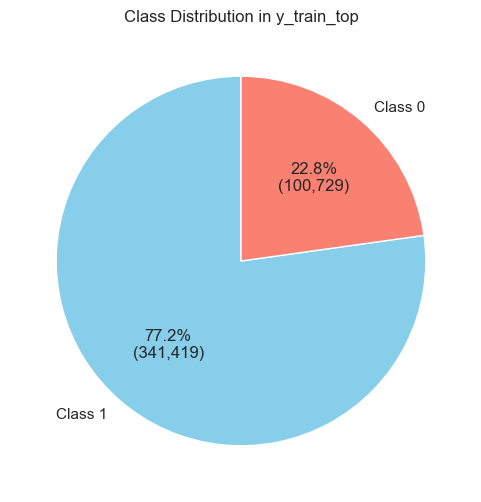

In [45]:
import matplotlib.pyplot as plt
from collections import Counter

# Count class distribution
class_counts = Counter(y_train_top)
labels = [f"Class {cls}" for cls in class_counts.keys()]
sizes = list(class_counts.values())

# Custom autopct to show % and counts
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: autopct_format(pct, sizes),
    startangle=90,
    colors=['skyblue', 'salmon']
)
plt.title("Class Distribution in y_train_top")
plt.show()

#### class balancing(Apply SMOTE).

In [46]:
#%pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_bal, y_train_bal = smote.fit_resample(X_train_top, y_train_top)

print("Before SMOTE:")
print(y_train_top.value_counts())

print("\nAfter SMOTE:")
print(y_train_bal.value_counts())

Before SMOTE:
1    341419
0    100729
Name: count, dtype: int64

After SMOTE:
1    341419
0    341419
Name: count, dtype: int64


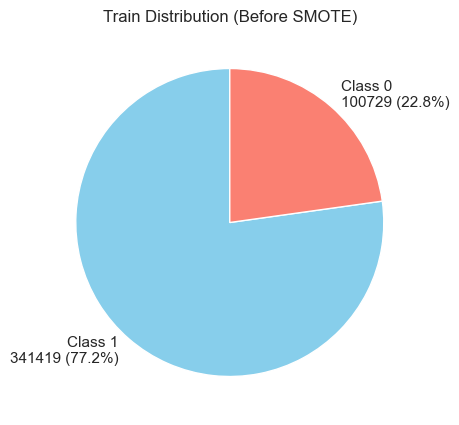

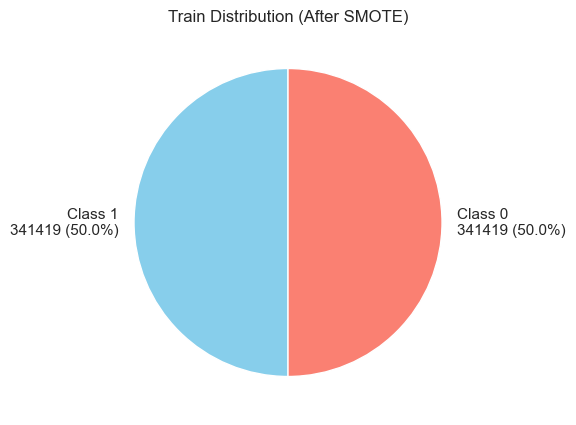

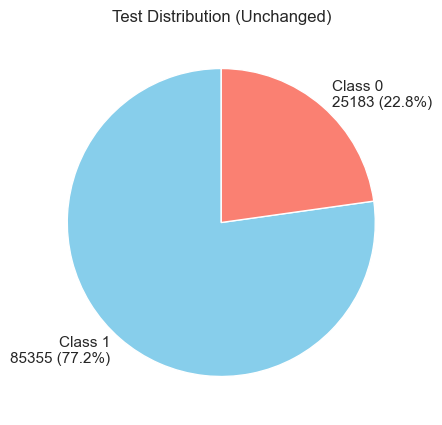

In [47]:
from collections import Counter

def plot_pie(y, title, colors=['skyblue', 'salmon']):
    class_counts = Counter(y)
    total = sum(class_counts.values())

    plt.figure(figsize=(5,5))
    plt.pie(
        class_counts.values(),
        labels=[f"Class {cls}\n{count} ({count/total:.1%})" for cls, count in class_counts.items()],
        startangle=90,
        colors=colors
    )
    plt.title(title)
    plt.show()

# Pie chart for y_train before SMOTE
plot_pie(y_train_top, "Train Distribution (Before SMOTE)")

# Pie chart for y_train after SMOTE
plot_pie(y_train_bal, "Train Distribution (After SMOTE)")

# Pie chart for y_test (remains imbalanced!)
plot_pie(y_test_top, "Test Distribution (Unchanged)")


From the above results we see that using the SMOTE we have balanced our data that had class imbalance and now its 50%-50% and to maintain reality the test data has still class imbalance but its fine because it perfectly represents real life situation.

### best classification model for the loan outcome

In [48]:
%pip install xgboost

# ================================
# Train & Compare Models
# ================================
import time
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, n_jobs=-1, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, n_jobs=-1, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, 
        eval_metric="logloss", use_label_encoder=False, 
        n_jobs=-1, random_state=42
    )
}

results = []

# Loop through models
for name, model in models.items():
    print(f"\n==== {name} ====")
    start = time.time()
    
    model.fit(X_train_bal, y_train_bal)   # Train on SMOTE-balanced data
    y_pred = model.predict(X_test_top)
    y_proba = model.predict_proba(X_test_top)[:,1] if hasattr(model, "predict_proba") else None
    
    end = time.time()
    runtime = end - start
    
    # Metrics
    auc = roc_auc_score(y_test_top, y_proba) if y_proba is not None else np.nan
    print(f"Training Time: {runtime:.2f} seconds")
    print(f"ROC-AUC: {auc:.3f}")
    print("\nClassification Report:\n", classification_report(y_test_top, y_pred))
    
    results.append({
        "Model": name,
        "Train Time (s)": round(runtime, 2),
        "ROC-AUC": round(auc, 3)
    })

# Create summary table
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("\n=== Model Comparison Summary ===")
print(results_df)

Note: you may need to restart the kernel to use updated packages.

==== Logistic Regression ====
Training Time: 19.59 seconds
ROC-AUC: 0.857

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.80      0.62     25183
           1       0.93      0.78      0.85     85355

    accuracy                           0.78    110538
   macro avg       0.72      0.79      0.73    110538
weighted avg       0.83      0.78      0.79    110538


==== Random Forest ====
Training Time: 66.69 seconds
ROC-AUC: 0.974

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86     25183
           1       0.96      0.95      0.96     85355

    accuracy                           0.93    110538
   macro avg       0.90      0.92      0.91    110538
weighted avg       0.93      0.93      0.93    110538


==== Gradient Boosting ====
Training Time: 568.64 seconds
ROC-AUC: 0.978

Classificat

For all the models trained, **Gradient Boosting achieved the highest ROC-AUC (0.978)**, but we used **XGBoost because it took the shortest time to train and had a high ROC-AUC of 0.977(second highest)**

### Training the final model

In [49]:
# ================================
# Final XGBoost Model Training
# ================================
import time
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define final XGBoost model with tuned parameters
final_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

# Train model
print("Training final XGBoost model...")
start = time.time()
final_xgb.fit(X_train_bal, y_train_bal)
end = time.time()
print(f"Training completed in {end - start:.2f} seconds.")

# Predictions on test set (original distribution, no SMOTE)
y_pred = final_xgb.predict(X_test_top)
y_proba = final_xgb.predict_proba(X_test_top)[:, 1]

# Evaluation metrics
roc_auc = roc_auc_score(y_test_top, y_proba)
print(f"\nFinal Test ROC-AUC: {roc_auc:.3f}")

print("\nClassification Report:\n")
print(classification_report(y_test_top, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_top, y_pred))


Training final XGBoost model...
Training completed in 4.03 seconds.

Final Test ROC-AUC: 0.977

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87     25183
           1       0.97      0.95      0.96     85355

    accuracy                           0.94    110538
   macro avg       0.91      0.92      0.91    110538
weighted avg       0.94      0.94      0.94    110538


Confusion Matrix:

[[22318  2865]
 [ 3853 81502]]


The final XGBoost model delivered excellent performance, achieving a **ROC-AUC of 0.977** on the test set, which indicates very strong discriminatory power between the two classes. The classification report shows a **high recall** and **precision** for the majority class (1), meaning the model is very effective at correctly identifying positive cases while keeping false positives low. For the minority class (0), the model achieved a precision of 0.85 and recall of 0.88, which is strong given the class imbalance. **The overall accuracy stood at 94%**, with both macro and weighted averages above 0.91, confirming balanced performance across classes. The confusion matrix further shows that most predictions were correct, with relatively few misclassifications. Overall, this final model is both accurate and efficient, making it highly suitable for deployment.

#### confussion matrix

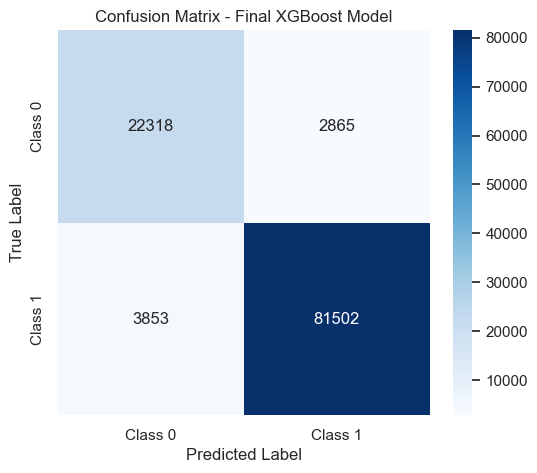

In [50]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test_top, y_pred)
labels = ["Class 0", "Class 1"]

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final XGBoost Model")
plt.show()

It correctly classified 22318 CHG_OOF miss clasified 3853 and for PIF it correctly classified 81502 and failed to classify 2865 accuracy was 94\%

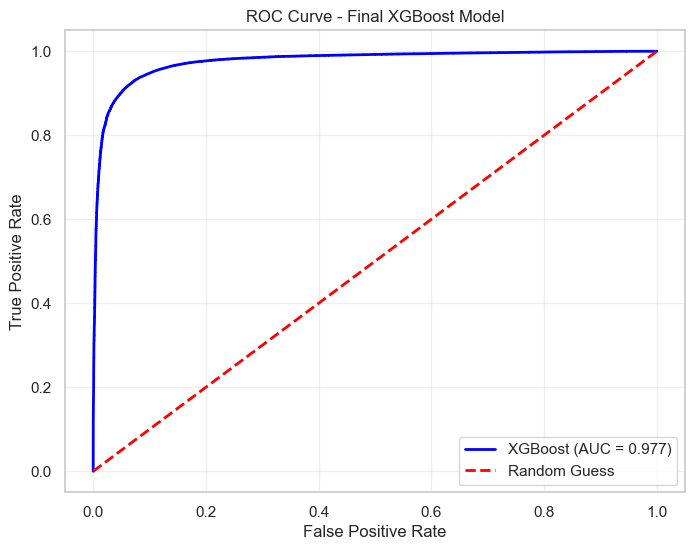

In [51]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities with final_xgb
y_proba = final_xgb.predict_proba(X_test_top)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_top, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color='red', linestyle="--", lw=2, label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

This ROC curve shows how well your XGBoost model distinguishes between the two classes. **The curve is very close to the top-left corner**, which indicates a high true positive rate with a low false positive rate. The AUC (Area Under the Curve) value of 0.977 confirms excellent discriminatory ability—values close to 1 indicate near-perfect performance. In simple terms, **our model is very effective at correctly classifying both default (1) and non-default (0) cases**.

### Predict sba_appv (regression)

                            bank  bank_state     naics      term  \
bank                    1.000000    0.483325  0.199476  0.282656   
bank_state              0.483325    1.000000  0.144111  0.121565   
naics                   0.199476    0.144111  1.000000  0.227968   
term                    0.282656    0.121565  0.227968  1.000000   
franchise_code          0.208821    0.140675  0.188305  0.235478   
balance_gross           0.000428    0.002098  0.003531  0.002886   
sba_appv                0.271118    0.124116  0.222186  0.566457   
rev_line_cr_clean       0.112261    0.119969  0.153560  0.356603   
log_no_emp              0.185742    0.076837  0.123948  0.194987   
log_disbursement_gross  0.372908    0.181376  0.251249  0.531559   
log_gr_appv             0.385633    0.200484  0.279914  0.575692   
retained_job_log       -0.086953   -0.106529 -0.025601 -0.034426   

                        franchise_code  balance_gross  sba_appv  \
bank                          0.208821       0.0

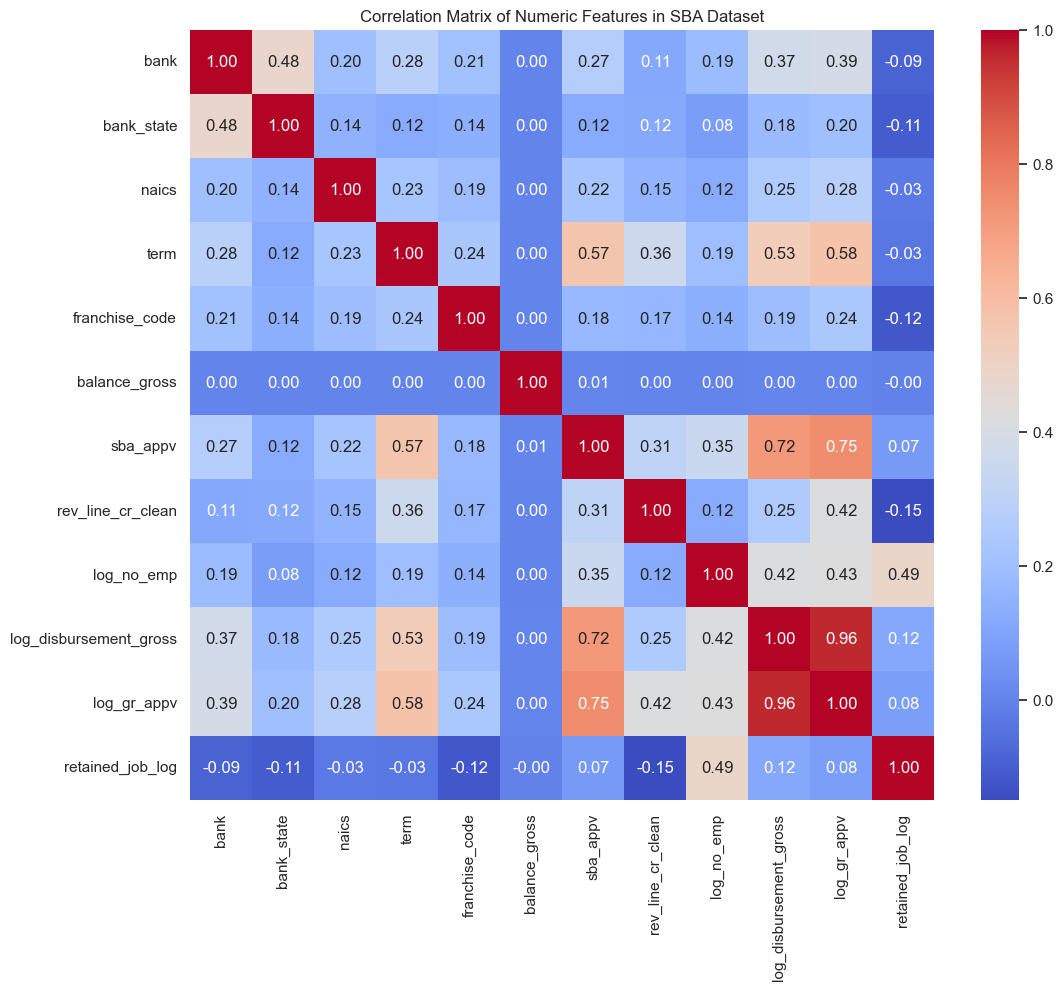

In [52]:
# Select only numeric columns
numeric_cols = sba1.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Display the matrix
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Numeric Features in SBA Dataset")
plt.show()

from our correlation matrix, the most correlated features are:
- log_gr_appv
- log_disbursement_gross
- term
- rev_line_cr_clean
- log_no_emp

In [53]:
features_sba = [
    'log_gr_appv', 'log_disbursement_gross', 'term',
    'rev_line_cr_clean', 'log_no_emp', 
]

X_reg_sba = sba1[features_sba]
y_sba = sba1['sba_appv']

# Train-test split
from sklearn.model_selection import train_test_split

X_train_sba, X_test_sba, y_train_sba, y_test_sba = train_test_split(
    X_reg_sba, y_sba, test_size=0.3, random_state=42
)

In [54]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import numpy as np

# Define models (CPU-only)
models_sba = {
    "LinearRegression": LinearRegression(),

    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": xgb.XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        tree_method="hist",     # CPU-compatible
        random_state=42,
        n_jobs=-1
    )
}

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate models using RMSE
for name, model in models_sba.items():
    scores = cross_val_score(
        model,
        X_train_sba,
        y_train_sba,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        error_score="raise"    # fail fast if anything is misconfigured
    )

    rmse_scores = -scores  # convert to positive RMSE
    print(f"{name}: Mean RMSE = {rmse_scores.mean():.2f}, Std = {rmse_scores.std():.2f}")

LinearRegression: Mean RMSE = 160057.56, Std = 2176.53
RandomForest: Mean RMSE = 39546.87, Std = 598.24
GradientBoosting: Mean RMSE = 36536.24, Std = 647.83
XGBoost: Mean RMSE = 49015.91, Std = 1066.81


#### Training final chosen model

In [55]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize GradientBoostingRegressor with standard parameters
final_gb_model = GradientBoostingRegressor(
    n_estimators=500,       # common default
    learning_rate=0.1,      # default
    max_depth=3,            # default
    subsample=1.0,          # default
    random_state=42
)

# Fit the model on the training set
final_gb_model.fit(X_train_sba, y_train_sba)

# Predictions
y_train_pred = final_gb_model.predict(X_train_sba)
y_test_pred = final_gb_model.predict(X_test_sba)

# Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train_sba, y_train_pred))
train_r2 = r2_score(y_train_sba, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test_sba, y_test_pred))
test_r2 = r2_score(y_test_sba, y_test_pred)

print(f"Train RMSE: {train_rmse:.2f}, R²: {train_r2:.2f}")
print(f"Test RMSE : {test_rmse:.2f}, R²: {test_r2:.2f}")

Train RMSE: 32628.93, R²: 0.98
Test RMSE : 35583.73, R²: 0.98


#### Diagnostic analysis -Actual vs Predicted

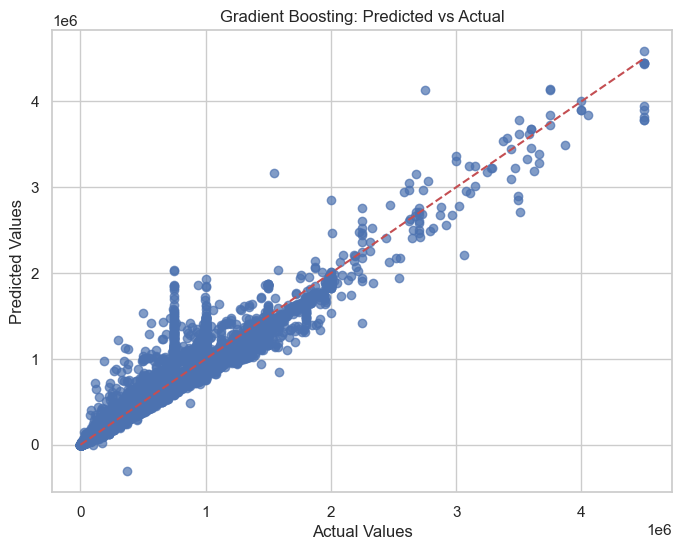

In [56]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_sba, y_test_pred, alpha=0.7)
plt.plot([y_test_sba.min(), y_test_sba.max()], [y_test_sba.min(), y_test_sba.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Gradient Boosting: Predicted vs Actual')
plt.show()

#### The ressidual plot

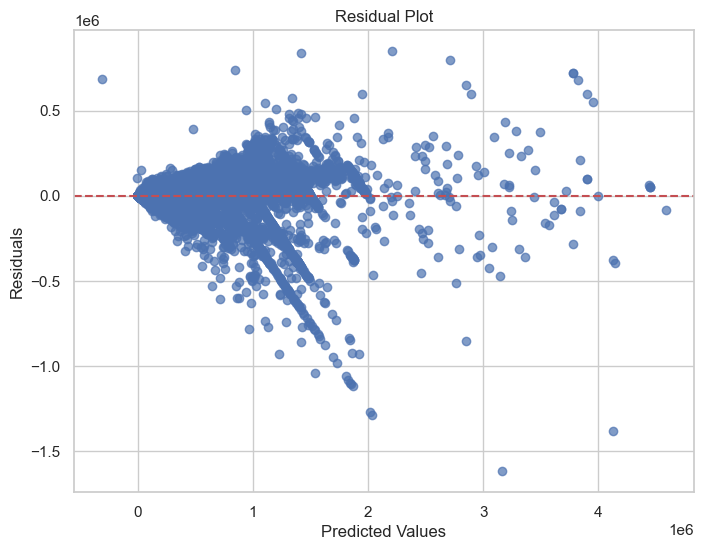

In [57]:
residuals = y_test_sba - y_test_pred
plt.figure(figsize=(8,6))
plt.scatter(y_test_pred, residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### Conclusion
This study analyzed historical SBA loan data from 1987 to 2014 to understand repayment patterns, identify key risk factors, and develop predictive models. Our analysis revealed that **term, Bank, naics and bank state were the most influential factors and the best model for predicting miss_status was XGBoost**.

For sba_appv the **log_gr_appv, log_disbursement_gross, term, rev_line_cr_clean, log_no_emp were the most influential factors and the best model for predicting sba_appv was GradientBoosting**